# Shape analysis

<h1>Shape analysis</h1>

<br/>
<p>
    <b>Quantitative Big Imaging</b> ETHZ: 227-0966-00L
    <br/>
    <b>Part 1</b>
</p>
<br/>

<div class='row'>
    <div class='column23'>
        <p style="font-size:1em;">March 26, 2026</p>
        <br /><br />
        <p style="font-size:1.5em;padding-bottom: 0.25em;">Anders Kaestner</p>  
        <p style="font-size:1em;">Laboratory for Neutron Scattering and Imaging<br />Paul Scherrer Institut</p>
    </div>
    <div class='column13'>
        <img src="figures/np_shape_2328381_000000.svg" style="height:300px" />
    </div>
</div>   

## Learning Objectives

### Motivation (Why and How?)
- How do we quantify where and __how big__ our objects are?
- How can we say something about the __shape__?
- How can we compare objects of __different sizes__?
- How can we __compare two images__ on the basis of the shape as calculated from the images?
- How can we put objects into an 
    - finite element simulation? 
    - or make pretty renderings?

## Outline

- Motivation (Why and How?)
- Object Characterization
- Volume
- Center and Extents
- Anisotropy

## Motivation

- We have dramatically simplified our data, but there is still too much.

- We perform an experiment to see how big the bone cells are inside the tissue:

- The work flow until now is

<div class="row">
    <div class="column13">

__Aquisition__ $\rightarrow$  
2560 x 2560 x 2160 x 32 bit  

- 56GB / sample
        
<img src="figures/tomoimage.png" style="width:500px" />
    </div>
    <div class="column13">

__Filtering__ $\rightarrow$  
2560 x 2560 x 2160 x 32 bit
 
- Still 56GB of less noisy data

     </div>
    <div class="column13">

__Segmentation__  
2560 x 2560 x 2160 x 1 bit = 1.75GB / sample

- 1.75GB is still an aweful lot of data
        
    </div>
</div>
<br /><br /><br /><br />

__... but we are not quantifying anything yet!__

### What did we want in the first place?

<div class="row">

<div class="column">   
<br/><br/><br/>    
    
_Single numbers_ :
- volume fraction,
- cell count,
- average cell stretch,
- cell volume variability

</div>
<div class="column">
<img src="figures/WeCanMeasureThis.png" style="height:600px"/>  
</div>

## Metrics

- Surface Area
- Counting
- Shape Tensor
- Principal Component Analysis
- Ellipsoid Representation
- Anisotropy, Oblateness
- Scale-free metrics
- Meshing
 - Marching Cubes
 - Isosurfaces


## Literature / Useful References

### General
- Jean Claude, [_Morphometry with R_](http://link.springer.com/book/10.1007%2F978-0-387-77789-4)
- John C. Russ, [_The Image Processing Handbook_](http://dx.doi.org/10.1201/9780203881095), Boca Raton, CRC Press

### Principal Component Analysis
- Venables, W. N. and B. D. Ripley (2002). [_Modern Applied Statistics with S_](https://doi.org/10.1007/978-0-387-21706-2), Springer-Verlag

### Shape Tensors
- Doube, M.,et al. (2010). [_BoneJ: Free and extensible bone image analysis in ImageJ_](https://doi.org/10.1016/j.bone.2010.08.023). Bone, 47, 1076–9.
- Mader, K. , et al. (2013). [_A quantitative framework for the 3D characterization of the osteocyte lacunar system_](https://doi:10.1016/j.bone.2013.06.026). Bone, 57(1), 142–154.
 
- Wilhelm Burger, Mark Burge (2009). [_Principles of Digital Image Processing: Core Algorithms_](https://doi.org/10.1007/978-1-84800-195-4). Springer-Verlag
-  B. Jähne (2005). [_Digital Image Processing_](https://doi.org/10.1007/3-540-27563-0). Springer-Verlag
-  T. H. Reiss (1993). [_Recognizing Planar Objects Using Invariant Image Features_](https://doi.org/10.1007/BFb0017553), from Lecture notes in computer science, p. 676. Springer
- [Image moments](http://en.wikipedia.org/wiki/Image_moment)
    
 

## Let's load some modules for python

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches     import Rectangle

from matplotlib.animation import FuncAnimation
from IPython.display      import HTML
from skimage.morphology   import label
from skimage.morphology   import erosion, disk
from skimage.measure      import regionprops
from skimage.io           import imread
from skimage.morphology   import label

from IPython.display        import Markdown, display
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.decomposition  import PCA
import webcolors
import sys
sys.path.append('../common')
import plotsupport as ps

from collections import defaultdict

%matplotlib inline

# Component labelling
__Segmentation__
- Segmentation identified pixels belonging to some class
    - a single set containing all pixels!
    
__To measure objects in an image, they need to be uniquely identified.__

Once we have a clearly segmented image, it is often helpful to identify the sub-components of this image. Connected component labeling is one of the first labeling algorithms you come across. This is the easist method for identifying these subcomponents which again uses the neighborhood $\mathcal{N}$ as a criterion for connectivity. The principle of the this algorithm class is that it is it puts labels on all pixels that touch each other. This means that the algorithm searches the neighborhood of each pixel and checks if it is marked as an object. If, "yes" then the neighbor pixel will be assigned the same class a the pixels we started from. This is an iterative process until each object in the image has one unique label.

In general, the approach works well since usually when different regions are touching, they are related. It runs into issues when you have multiple regions which agglomerate together, for example a continuous pore network (1 object) or a cluster of touching cells.

## Basic component labelling
- give the same label to all pixels touching each other.
- has its drawbacks... touching item are treated as one

In [2]:
img = np.zeros((100,100))
img[20:30,10:40]=1
img[30:60,60:80]=1
img[60:90,10:20]=1

lbl = label(img)

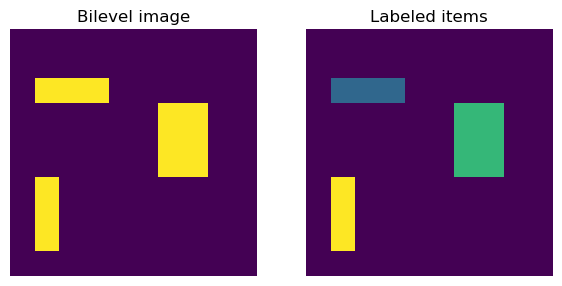

In [3]:
# visualization
fig,ax=plt.subplots(1,2,figsize=(7,4))
ax[0].imshow(img, interpolation='none'), ax[0].axis('off')
ax[0].set_title('Bilevel image');
ax[1].imshow(lbl,interpolation='none'),ax[1].axis('off')
ax[1].set_title('Labeled items');

## A cityscape image 

To demonstrate the connected components labeling we need an image. Here, we show some examples from Cityscape Data taken in Aachen (https://www.cityscapes-dataset.com/). The picture represents a street with cars in a city. The cars are also provided as a segmentation mask. This saves us the trouble of finding them in the first place.

image dimensions (256, 512, 4) (256, 512)


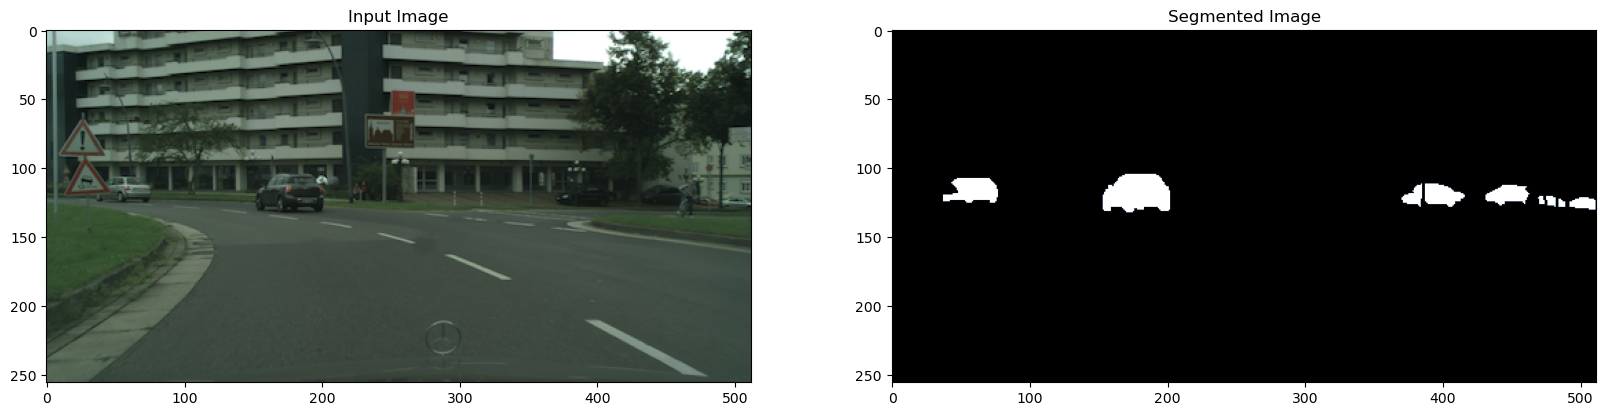

In [4]:
car_img = imread('figures/aachen_img.png')
seg_img = imread('figures/aachen_label.png')[::4, ::4] == 26
print('image dimensions', car_img.shape, seg_img.shape)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
ax1.imshow(car_img)
ax1.set_title('Input Image')

ax2.imshow(seg_img, cmap='bone')
ax2.set_title('Segmented Image');

## Connected component labeling in python

In [5]:
from skimage.morphology import label
help(label)

Help on function label in module skimage.measure._label:

label(label_image, background=None, return_num=False, connectivity=None)
    Label connected regions of an integer array.
    
    Two pixels are connected when they are neighbors and have the same value.
    In 2D, they can be neighbors either in a 1- or 2-connected sense.
    The value refers to the maximum number of orthogonal hops to consider a
    pixel/voxel a neighbor::
    
      1-connectivity     2-connectivity     diagonal connection close-up
    
           [ ]           [ ]  [ ]  [ ]             [ ]
            |               \  |  /                 |  <- hop 2
      [ ]--[x]--[ ]      [ ]--[x]--[ ]        [x]--[ ]
            |               /  |  \             hop 1
           [ ]           [ ]  [ ]  [ ]
    
    Parameters
    ----------
    label_image : ndarray of dtype int
        Image to label.
    background : int, optional
        Consider all pixels with this value as background pixels, and label
       

## Labels in the cityscape image

When we apply the ```label``` operation on the car mask, we see the that each car is assigned a color. There are however some cars that get multiple classes. This is because they were divided into several segments due to objects like tree and trafic signs.

In [6]:
from skimage.morphology import label
lab_img = label(seg_img)

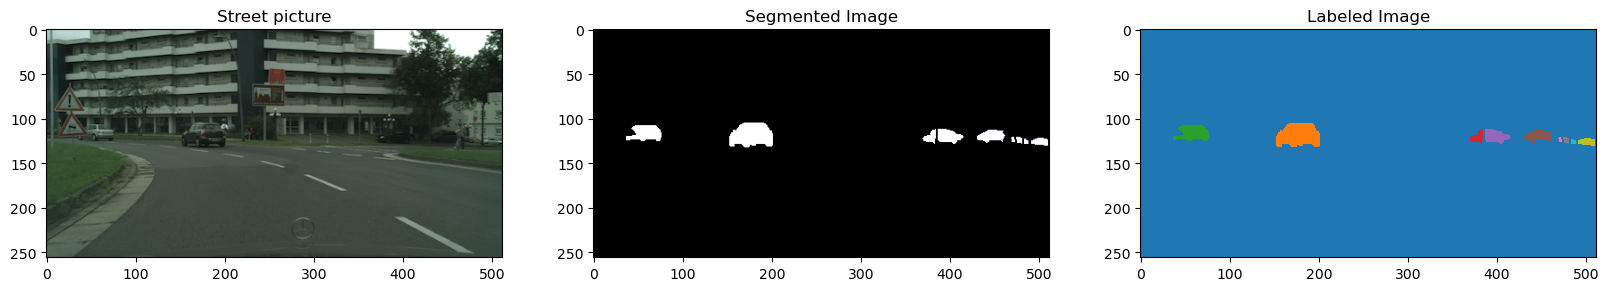

In [7]:
fig, (ax0,ax1, ax2) = plt.subplots(1, 3, figsize=(20, 8), dpi=100)
ax0.imshow(car_img)
ax0.set_title('Street picture') 
ax1.imshow(seg_img, cmap='bone')
ax1.set_title('Segmented Image')  
ax2.imshow(lab_img, cmap=plt.cm.tab10,interpolation='none')
ax2.set_title('Labeled Image');

## Area of each segment

Now, we can start making measurements in the image. A first thing that comes to mind is to compute the area of the objects. This is a very simple operation; we only have to count the number of pixels belonging to each label.

$$Area_i=\#\{x|f(x)\in{}i\}$$

#### Python coding

In [8]:
lbls = np.unique(lab_img)
areas = []
for L in lbls :
    areas.append(lab_img[lab_img==L].sum())
    
df = pd.DataFrame({'lbl': lbls, 'area' : areas})
df.transpose()

,0,1,2,3,4,5,6,7,8,9
lbl,0,1,2,3,4,5,6,7,8,9
area,0,1091,1070,420,1368,1615,132,308,1072,225


#### Using the histogram

Usually, we want to know the are of all items in the images. We could do this by writing a loop that goes through all labels in the image and compute each one of them. There is however an operation that does this much easier: the histogram.

We can use a histogram with the same number of bins are there are labels in the image. This would give us the size distribution in of the objects in one single operation.

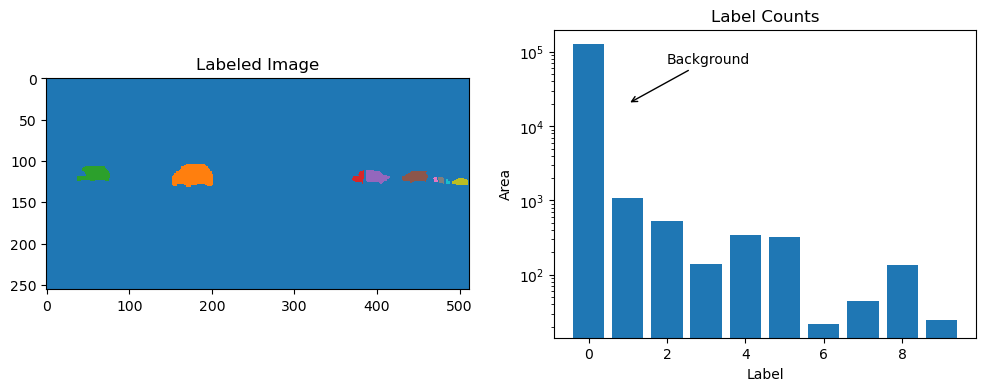

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].imshow(lab_img, cmap=plt.cm.tab10,interpolation='none')
ax[0].set_title('Labeled Image');
# ax[1].hist(lab_img.ravel())

hb,ha = np.histogram(lab_img.ravel(),bins=np.arange(0,lab_img.max()-lab_img.min()+2))

plt.bar(ha[:-1],hb ,align="center")

ax[1].set_title('Label Counts')
ax[1].set_yscale('log')
ax[1].set_xlabel('Label')
ax[1].set_ylabel('Area');

ax[1].annotate("Background",xy=(1,2e4),xytext=(2,7e4),arrowprops={"arrowstyle":"->"});

# A component labeling algorithm

We start off with all of the pixels in either foreground (1) or background (0)

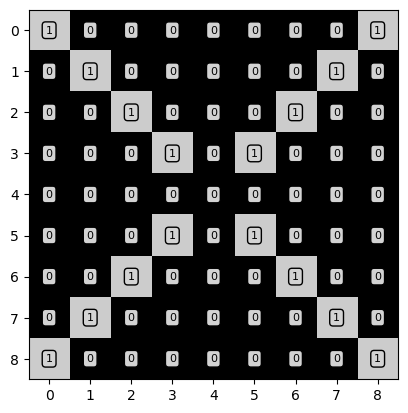

In [10]:
seg_img = np.eye(9, dtype=int)
seg_img[4, 4] = 0
seg_img += seg_img[::-1] 
ps.heatmap(seg_img,cmap='nipy_spectral',fontsize=8,precision=0);

## Labeling initialization
Give each point in the image a unique label
- For each point $(x,y)\in\text{Foreground}$
 - Set value to $I_{x,y} = x+y*width+1$

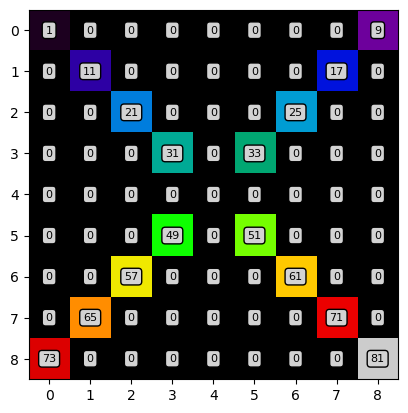

In [11]:
idx_img = np.zeros_like(seg_img)

x,y = np.meshgrid(np.arange(0,seg_img.shape[0]),np.arange(0,seg_img.shape[1]))

nonzero = seg_img>0
idx_img[nonzero] = x[nonzero]+y[nonzero]*seg_img.shape[0]+1

ps.heatmap(idx_img,cmap='nipy_spectral',fontsize=8,precision=0);

## A brushfire labeling algorithm

In a [brushfire](http://www.sciencedirect.com/science/article/pii/S0921889007000966)-style algorithm
- For each point $(x,y)\in\text{Foreground}$
    - For each point $(x^{\prime},y^{\prime})\in\mathcal{N}(x,y)$
    - if $(x^{\prime},y^{\prime})\in\text{Foreground}$
        - Set the label to $\max(I_{x,y}, I_{x^{\prime},y^{\prime}})$
- Repeat until no more labels have been changed

> Note: Local maximum is the same as gray level dilation.

### Implementation of the brush fire algorithm

In [12]:
import skimage.morphology as morph

def brushfire(img,footprint=np.ones([3,3]),Niterations=4):
    last_img = img.copy()
    img_list = [last_img]

    mask = last_img > 0 
    it_list = []
    for iteration in range(Niterations):
        cur_img = morph.dilation(last_img,footprint=footprint) * mask

        img_list.append(cur_img)

        if (cur_img == last_img).all():
            print('Done')
            break
        else:
            print('Iteration', iteration,
                  'Groups', len(np.unique(cur_img[cur_img > 0].ravel())),
                  'Changes', np.sum(cur_img != last_img))
            it_list.append({'Iteration': iteration, 'Groups' : len(np.unique(cur_img[cur_img > 0].ravel())), 'Changes' : np.sum(cur_img != last_img)})
            last_img = cur_img
            
    return img_list,it_list

Implementing the brushfire as described above would require four nested loops which is quite hard to understand.  

Therefore we implement the algorithm using the grayscale dilation operation, which provides a local maximum for each pixel in the image. The problem with the dilation is that it acts on all pixels, not only the pixels belongning to the structure. This results in an image with more foreground pixels than before. The solution is to mask the result with the foreground pixels. 

### Looking at the iterations

In [13]:
img_list,it_list = brushfire(idx_img)

Iteration 0 Groups 12 Changes 12
Iteration 1 Groups 8 Changes 8
Iteration 2 Groups 4 Changes 4
Done


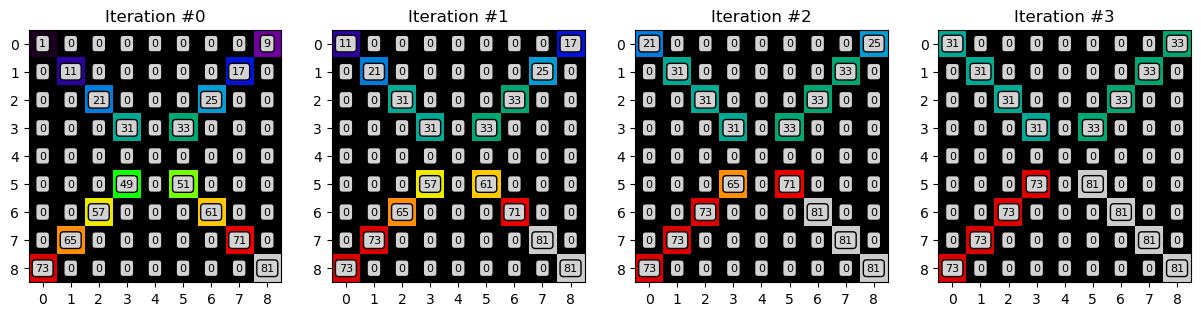

In [14]:
fig, m_axs = plt.subplots(1, 4, figsize=(15, 5)); m_axs=m_axs.ravel()
for idx,(c_ax,cur_img) in enumerate(zip(m_axs,img_list)):
    ps.heatmap(cur_img,cmap='nipy_spectral',fontsize=8,precision=0,ax=c_ax);
    c_ax.set_title('Iteration #{}'.format(idx))

### Let's animate the iterations

In [15]:
%matplotlib inline
fig, c_ax = plt.subplots(1, 1, figsize=(5, 5), dpi=100)

def update_frame(i):
    plt.cla()
    ps.heatmap(img_list[i],cmap='nipy_spectral',fontsize=8,precision=0,ax=c_ax);

    c_ax.set_title('Iteration #{}, Groups {}'.format(i+1,
                                                     len(np.unique(img_list[i][img_list[i] > 0].ravel()))))
# write animation frames
anim_code = FuncAnimation(fig, update_frame, frames=len(img_list)-1,
                          interval=1000, repeat_delay=2000).to_html5_video()


plt.close('all')
HTML(anim_code)

### Some comments on the brushfire algorithm
- The image very quickly converges and after 4 iterations the task is complete. 

- For larger more complicated images with thousands of components this task can take longer, 
- There exist much more efficient [algorithms](https://www.cs.princeton.edu/~rs/AlgsDS07/01UnionFind.pdf) for labeling components which alleviate this issue.
    - [Rosenfeld & Pfalz, _Sequential Operations in Digital Picture Processing_, 1966](https://doi.org/10.1145/321356.321357)
    - [Soille, Morphological Image Processing, page 38, 2004](https://doi.org/10.1007/978-3-662-05088-0)
    - [Wikipedia](https://en.wikipedia.org/wiki/Connected-component_labeling)

## Bigger Images
How does the same algorithm apply to bigger images?

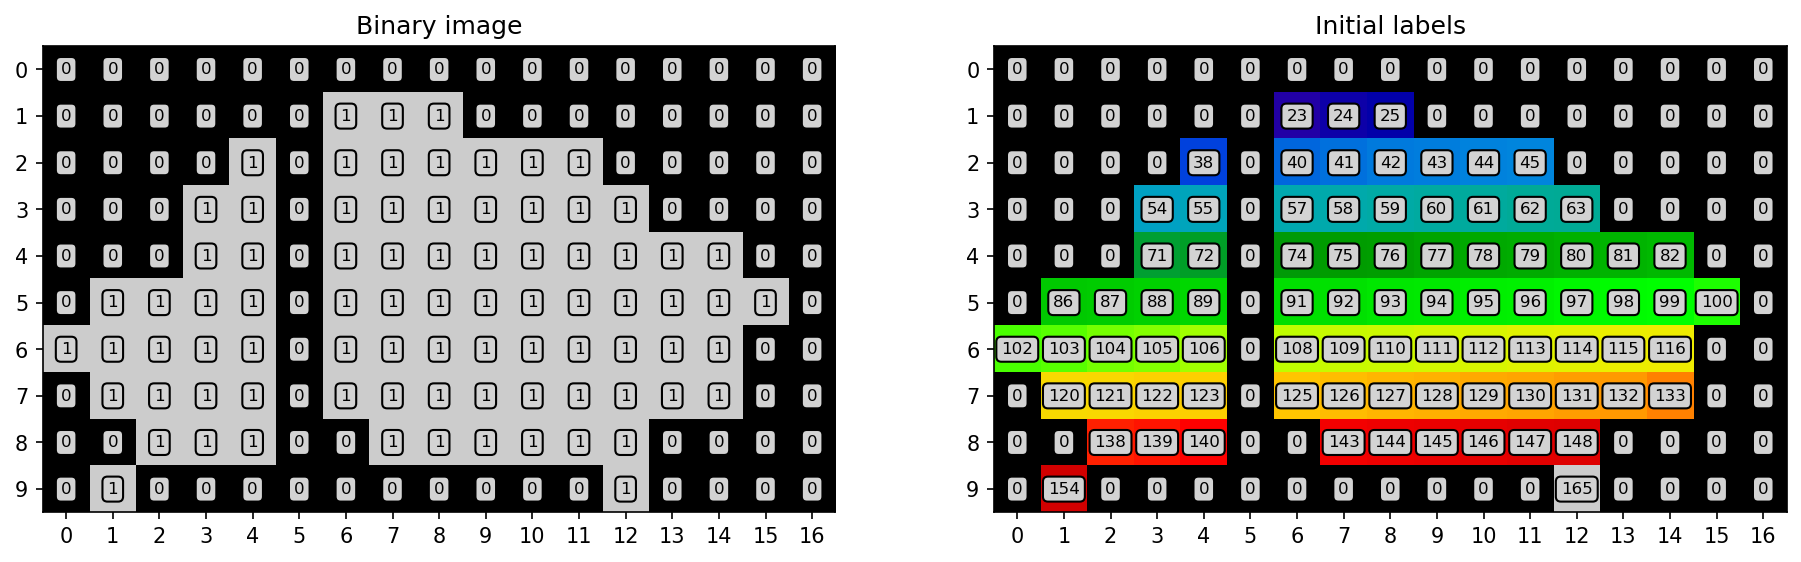

In [16]:
seg_img = (imread('figures/aachen_label.png')[::4, ::4] == 26)[110:130:2, 370:420:3]
seg_img[9, 1] = 1
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), dpi=150)
ps.heatmap(seg_img,cmap='nipy_spectral',fontsize=8,precision=0,ax=ax1);
ax1.set_title('Binary image')

idx_img = seg_img * np.arange(len(seg_img.ravel())).reshape(seg_img.shape)
ps.heatmap(idx_img,cmap='nipy_spectral',fontsize=8,precision=0,ax=ax2);
ax2.set_title('Initial labels');

### Run the labelling on the car image

In [17]:
img_list3,it3=brushfire(idx_img,Niterations=99)

Iteration 0 Groups 62 Changes 78
Iteration 1 Groups 45 Changes 75
Iteration 2 Groups 31 Changes 68
Iteration 3 Groups 21 Changes 52
Iteration 4 Groups 13 Changes 37
Iteration 5 Groups 7 Changes 23
Iteration 6 Groups 3 Changes 10
Iteration 7 Groups 2 Changes 3
Done


### Let's animate the iterations

In [18]:

fig, c_ax = plt.subplots(1, 1, figsize=(8, 6))

def update_frame(i):
    plt.cla()
    ps.heatmap(img_list3[i],cmap='nipy_spectral',fontsize=8,precision=0,ax=c_ax);
    c_ax.set_title('Iteration #{}, Groups {}'.format(i+1,
                                                     len(np.unique(img_list3[i][img_list3[i] > 0].ravel()))))


# write animation frames
anim_code = FuncAnimation(fig,
                          update_frame,
                          frames=len(img_list3)-1,
                          interval=500,
                          repeat_delay=1000).to_html5_video()
plt.close('all')
HTML(anim_code)

## Different Neighborhoods
We can expand beyond the 3x3 neighborhood to a 5x5 for example

In [19]:
img_list5,it5=brushfire(idx_img,footprint=np.ones([5,5]),Niterations=99)

Iteration 0 Groups 48 Changes 79
Iteration 1 Groups 23 Changes 67
Iteration 2 Groups 7 Changes 37
Iteration 3 Groups 2 Changes 16
Iteration 4 Groups 2 Changes 10
Iteration 5 Groups 1 Changes 5
Done


### Animate the 5x5 labeling iterations

In [20]:
fig, c_ax = plt.subplots(1, 1, figsize=(8, 6))

def update_frame(i):
    plt.cla()

    ps.heatmap(img_list5[i],cmap='nipy_spectral',fontsize=8,precision=0,ax=c_ax);
    c_ax.set_title('Iteration #{}, Groups {}'.format(i+1,
                                                     len(np.unique(img_list5[i][img_list5[i] > 0].ravel()))))

# write animation frames
anim_code = FuncAnimation(fig,
                          update_frame,
                          frames=len(img_list5)-1,
                          interval=500,
                          repeat_delay=1000).to_html5_video()
plt.close('all')
HTML(anim_code)

## Or a smaller kernel
By using a smaller kernel (in this case where $\sqrt{x^2+y^2}<=1$, we cause the number of iterations to fill to increase and prevent the last pixel from being grouped since it is only connected diagonally

|   |   |   |
|--:|--:|--:|
|  0|  1|  0|
|  1|  1|  1|
|  0|  1|  0|


In [21]:
img_list1,it1=brushfire(idx_img,footprint=np.array([[0,1,0],[1,1,1],[0,1,0]]),Niterations=99)

Iteration 0 Groups 68 Changes 77
Iteration 1 Groups 54 Changes 74
Iteration 2 Groups 42 Changes 69
Iteration 3 Groups 31 Changes 61
Iteration 4 Groups 21 Changes 52
Iteration 5 Groups 12 Changes 43
Iteration 6 Groups 10 Changes 31
Iteration 7 Groups 9 Changes 24
Iteration 8 Groups 8 Changes 18
Iteration 9 Groups 7 Changes 13
Iteration 10 Groups 6 Changes 9
Iteration 11 Groups 5 Changes 6
Iteration 12 Groups 4 Changes 3
Iteration 13 Groups 3 Changes 1
Done


### Animate the cross labeling iterations

In [22]:
fig, c_ax = plt.subplots(1, 1, figsize=(8, 6))


def update_frame(i):
    plt.cla()

    ps.heatmap(img_list1[i],cmap='nipy_spectral',fontsize=8,precision=0,ax=c_ax);
    c_ax.set_title('Iteration #{}, Groups {}'.format(i+1,
                                                     len(np.unique(img_list1[i][img_list1[i] > 0].ravel()))))


# write animation frames
anim_code = FuncAnimation(fig,
                          update_frame,
                          frames=len(img_list1)-1,
                          interval=500,
                          repeat_delay=1000).to_html5_video()
plt.close('all')
HTML(anim_code)

## Comparing different neighborhoods

|Neighborhood size|Iterations| Segments |
|----------------:|---------:|---------:|
|      3x3        |    9     |    2     |
|      5x5        |    5     |    1     |
|      cross      |    14    |    3     |     

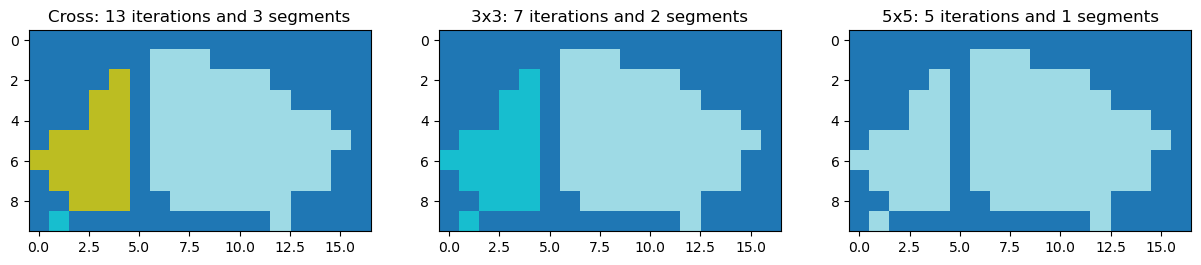

In [23]:
fig,ax = plt.subplots(1,3,figsize=(15,4))

cmap='tab20'
ax[0].imshow(img_list1[-1],cmap=cmap)
ax[0].set_title('Cross: {0} iterations and {1} segments'.format(it1[-1]['Iteration'],it1[-1]['Groups']))
ax[1].imshow(img_list3[-1],cmap=cmap)
ax[1].set_title('3x3: {0} iterations and {1} segments'.format(it3[-1]['Iteration'],it3[-1]['Groups']))
ax[2].imshow(img_list5[-1],cmap=cmap)
ax[2].set_title('5x5: {0} iterations and {1} segments'.format(it5[-1]['Iteration'],it5[-1]['Groups']));

# Beyond component labeling - what can we measure?


Now all the voxels which are connected have the same label. We can then perform simple metrics like

- counting the number of voxels in each label to estimate volume.
- looking at the change in volume during erosion or dilation to estimate surface area

## What we would like to to do

- Count the cells
- Say something about the cells
- Compare the cells in this image to another image


... But where do we start?

## Object position - Center of Volume (COV): With a single object

$$ I_{id}(x,y) = 
\begin{cases}
1, & L(x,y) = id \\
0, & \text{otherwise}
\end{cases}$$


The first step to compute the COV of an item is to label the image to be able to tell which pixels belong to each object. The equation above creates a set of pixels beloning to the item with label _id_.

In [24]:
seg_img = imread('figures/aachen_label.png') == 26
seg_img = seg_img[::4, ::4]
seg_img = seg_img[110:130:2, 370:420:3]
seg_img[9, 1] = 1
lab_img = label(seg_img)

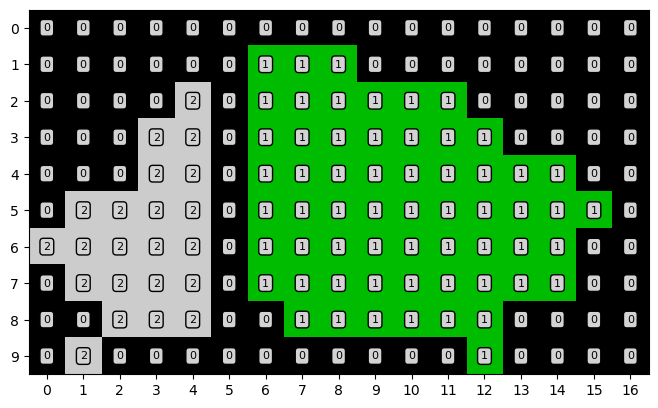

In [25]:
# Visualization
fig, ax = plt.subplots(figsize=[8,6],dpi=100)

ps.heatmap(lab_img,cmap='nipy_spectral',fontsize=8,precision=0,ax=ax);

We used our own labeling algorithm in the previous examples. That algorithm is good to demonstrate the principle, but is not so efficient. Therefore, will use the ```label``` function from SciKit Image from now on.

### Define a center

The center is defined by the coordinates of the item along each image axis, i.e., the coordinate pair x,y for a 2D image and x,y,z for a 3D image. Each coordinate component can be computed independently from the other as the axes are orthogonal like:

$$ \bar{x} = \frac{1}{N} \sum_{\vec{v}\in I_{id}} \vec{v}\cdot\vec{i} $$
$$ \bar{y} = \frac{1}{N} \sum_{\vec{v}\in I_{id}} \vec{v}\cdot\vec{j} $$
$$ \bar{z} = \frac{1}{N} \sum_{\vec{v}\in I_{id}} \vec{v}\cdot\vec{k} $$

i.e. the average position of all pixels in each direction.

### Center of a labeled item

Now, we look into a way to compute the center of an item in the image. The image has been labeled as preparations for the task. There are different ways to solve this task. The one you see here is easier to comprehend and provides a table with each coordinate in $I_{id}$, but is not the most efficient.

In [26]:
x_coord, y_coord = [], []
for x in range(lab_img.shape[0]):
    for y in range(lab_img.shape[1]):
        if lab_img[x, y] == 2:
            x_coord += [x]
            y_coord += [y]
            
cx = np.mean(x_coord)
cy = np.mean(y_coord)

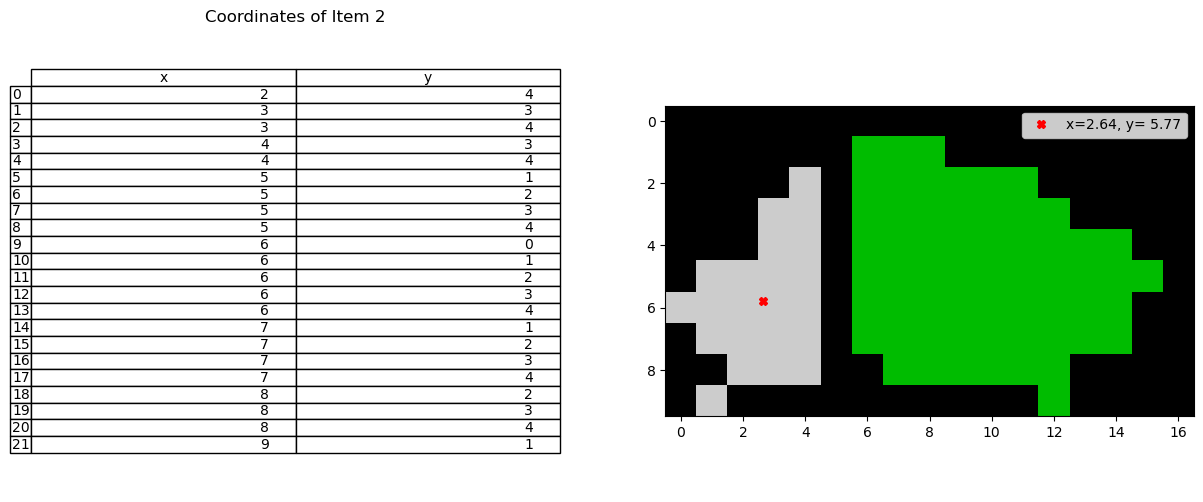

In [27]:
fig, ax = plt.subplots(1,2,figsize=[15,6],dpi=100)
items = pd.DataFrame.from_dict({'x': x_coord, 'y': y_coord})
#ps.heatmap(lab_img,cmap='nipy_spectral',fontsize=8,precision=0,ax=ax[1]);
plt.imshow(lab_img,cmap='nipy_spectral');
ax[1].plot(np.mean(y_coord),np.mean(x_coord),'rX',
        label="x={0:0.2f}, y= {1:0.2f}".format(cy , cx))
ax[1].legend()

pd.plotting.table(data=items, ax=ax[0], loc='center')
ax[0].set_title('Coordinates of Item 2'); ax[0].axis('off');

## Center of Mass (COM): With a single object

If the gray values are kept (or other meaningful ones are used), this can be seen as a weighted center of volume or center of mass (using $I_{gy}$ to distinguish it from the labels)

### Define a center

<div class="row">
<div class="column">

$$ \bar{x} = \frac{1}{\Sigma I_{gy}} \sum_{\vec{v}\in I_{id}} (\vec{v}\cdot\vec{i}) I_{gy}(\vec{v}) $$
$$ \bar{y} = \frac{1}{\Sigma I_{gy}} \sum_{\vec{v}\in I_{id}} (\vec{v}\cdot\vec{j}) I_{gy}(\vec{v}) $$
$$ \bar{z} = \frac{1}{\Sigma I_{gy}} \sum_{\vec{v}\in I_{id}} (\vec{v}\cdot\vec{k}) I_{gy}(\vec{v}) $$
        
</div>
<div class="column">
    
$$ \Sigma I_{gy} = \frac{1}{N} \sum_{\vec{v}\in I_{id}} I_{gy}(\vec{v}) $$
    
</div></div>


### Demonstrating the center of mass
We need an image for the demonstration

In [3]:
xx, yy = np.meshgrid(np.linspace(0, 10, 50),
                     np.linspace(0, 10, 50))
gray_img = 100*(np.abs(xx*yy-7) + np.square(yy-4))+0.25
gray_img *= np.abs(xx-5) < 3
gray_img *= np.abs(yy-5) < 3
gray_img[gray_img > 0] += 5
seg_img = (gray_img > 0).astype(int)

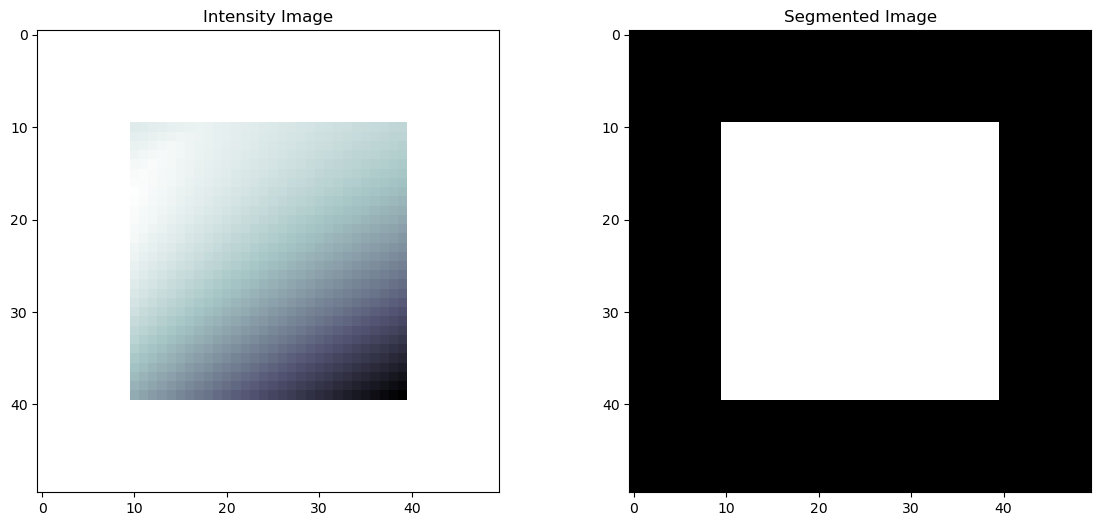

In [5]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.imshow(gray_img,cmap='bone_r')
ax1.set_title('Intensity Image')

ax2.imshow(seg_img,cmap='bone')
ax2.set_title('Segmented Image');

### Compare COM and COV

Both COV and COM provide a center metric. The difference is that the COV only considers the shape of the object while COM adds the weight of the gray level distribution in the calculation.

In [30]:
# Collect information
x_coord, y_coord, i_val = [], [], []
for x in range(seg_img.shape[0]):
    for y in range(seg_img.shape[1]):
        if seg_img[x, y] == 1:
            x_coord += [x]
            y_coord += [y]
            i_val   += [gray_img[x, y]]

x_coord = np.array(x_coord)
y_coord = np.array(y_coord)
i_val   = np.array(i_val)

cov_x   = np.mean(x_coord)
cov_y   = np.mean(y_coord)
com_x   = np.mean(x_coord*i_val)/i_val.mean()
com_y   = np.mean(y_coord*i_val)/i_val.mean()

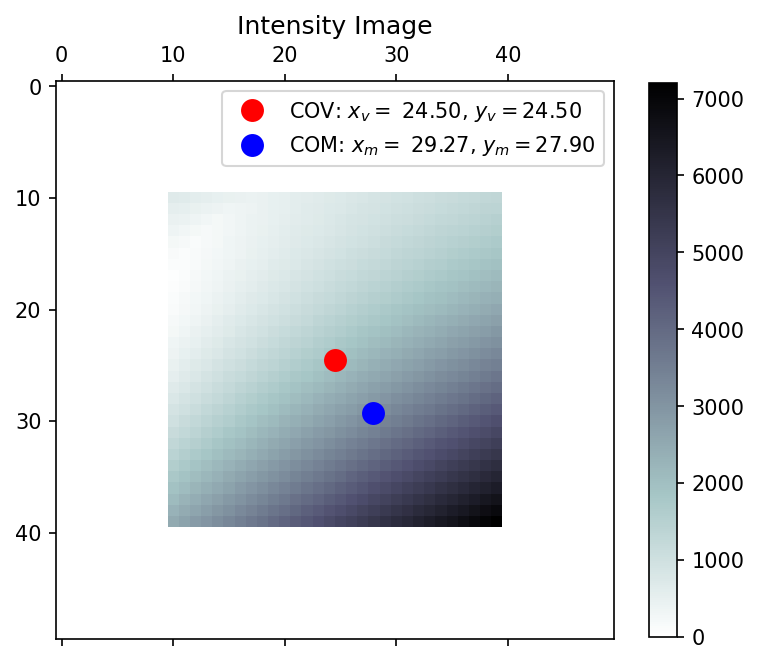

In [31]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 6), dpi=150)

im=ax1.matshow(gray_img,cmap='bone_r'); fig.colorbar(im,ax=ax1, shrink=0.8)
ax1.set_title('Intensity Image')
ax1.plot([cov_y], [cov_x], 'ro', label='COV: $x_v=$ {0:0.2f}, $y_v=${1:0.2f}'.format(cov_x,cov_y), markersize=10)
ax1.plot([com_y], [com_x], 'bo', label='COM: $x_m=$ {0:0.2f}, $y_m=${1:0.2f}'.format(com_x,com_y), markersize=10); ax1.legend();

## Further object metrics

The center tells the position of an object. 

We want more! E.g. metrics like:
- Area
- Perimeter length
- Sphericity 
- Orientation

... and more

```regionprops``` gives us all this!


### Regionprops manual page

In [32]:
from skimage.measure import regionprops
help(regionprops)

Help on function regionprops in module skimage.measure._regionprops:

regionprops(label_image, intensity_image=None, cache=True, *, extra_properties=None, spacing=None, offset=None)
    Measure properties of labeled image regions.
    
    Parameters
    ----------
    label_image : (M, N[, P]) ndarray
        Labeled input image. Labels with value 0 are ignored.
    
        .. versionchanged:: 0.14.1
            Previously, ``label_image`` was processed by ``numpy.squeeze`` and
            so any number of singleton dimensions was allowed. This resulted in
            inconsistent handling of images with singleton dimensions. To
            recover the old behaviour, use
            ``regionprops(np.squeeze(label_image), ...)``.
    intensity_image : (M, N[, P][, C]) ndarray, optional
        Intensity (i.e., input) image with same size as labeled image, plus
        optionally an extra dimension for multichannel data. Currently,
        this extra channel dimension, if present, must

### Let's try regionprops on our image

In [33]:
from skimage.measure import regionprops_table
safe_props = [
    'label', 'area', 'bbox_area', 'centroid', 'convex_area','eccentricity', 'equivalent_diameter', 'euler_number',
    'extent', 'feret_diameter_max', 'filled_area', 'inertia_tensor', 'inertia_tensor_eigvals',
    'major_axis_length', 'minor_axis_length', 'moments_hu', 'orientation', 'perimeter', 'perimeter_crofton', 'solidity']

all_regs = regionprops_table(seg_img, intensity_image=gray_img, properties=safe_props)
attr_df=pd.DataFrame.from_dict(all_regs, orient="index")

attr_df

,0
label,1.000000
area,900.000000
bbox_area,900.000000
centroid-0,24.500000
centroid-1,24.500000
convex_area,900.000000
eccentricity,0.000000
equivalent_diameter,33.851375
euler_number,1.000000
extent,1.000000


### Lots of information 
We can tell a lot about each object now, but...
- Too abstract
- Too specific

Ask biologists in the class if they ever asked 
- "How long is a cell in the $x$ direction?"
- "how about $y$?"

### When we know which properties we need

We saw before that the ```regionprops``` function provides a long list of properties. Most of them are often irrelevant for our measurements. We can, therefore, specify which properties we really want to measure. The next example uses a variation ```regionprops_table``` of the regionprops function which is better to use if we want to put the measurements in a dataframe. This function requires a list of properties which makes it less convenient if we want all properties. 

Let's say we want the properties ```area```,```perimeter```, and ```centroid```

In [34]:
from skimage.measure import regionprops_table
attr = regionprops_table(seg_img, intensity_image=gray_img, properties=['area','perimeter', 'centroid'])

attr_df=pd.DataFrame.from_dict(attr, orient="index")
attr_df

,0
area,900.0
perimeter,116.0
centroid-0,24.5
centroid-1,24.5


## Extents: With a single object

Exents or caliper lenghts are the size of the object in a given direction. Since the coordinates of our image our $x$ and $y$ the extents are calculated in these directions

Define extents as the minimum and maximum values along the projection of the shape in each direction
$$ \text{Ext}_x = \left\{ \forall \vec{v}\in I_{id}: max(\vec{v}\cdot\vec{i})-min(\vec{v}\cdot\vec{i})  \right\} $$
$$ \text{Ext}_y = \left\{ \forall \vec{v}\in I_{id}: max(\vec{v}\cdot\vec{j})-min(\vec{v}\cdot\vec{j})  \right\} $$
$$ \text{Ext}_z = \left\{ \forall \vec{v}\in I_{id}: max(\vec{v}\cdot\vec{k})-min(\vec{v}\cdot\vec{k})  \right\} $$

### Where is this information useful?

#### Let's look at a car item

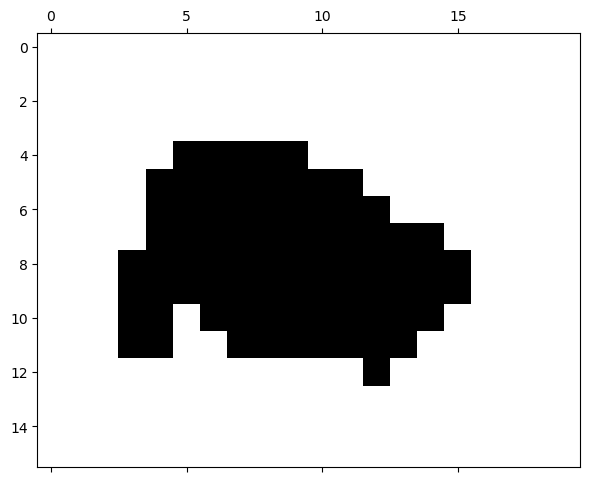

In [35]:
seg_img = imread('figures/aachen_label.png') == 26
seg_img = seg_img[::4, ::4]
seg_img = seg_img[110:130:2, 378:420:3] > 0
seg_img = np.pad(seg_img, 3, mode='constant')
_, (ax1) = plt.subplots(1, 1,
                        figsize=(7, 7),
                        dpi=100)
ax1.matshow(seg_img,
            cmap='bone_r');

### Finding a bounding box

In [36]:
# Find all coordinates in an object
x_coord, y_coord = [], []
for x in range(seg_img.shape[0]):
    for y in range(seg_img.shape[1]):
        if seg_img[x, y] == 1:
            x_coord += [x]
            y_coord += [y]
            
xmin = np.min(x_coord)
xmax = np.max(x_coord)
ymin = np.min(y_coord)
ymax = np.max(y_coord)
print('X -> ', 'Min:', xmin,'Max:', xmax)
print('Y -> ', 'Min:', ymin,'Max:', ymax)

X ->  Min: 4 Max: 12
Y ->  Min: 3 Max: 15


### Draw the box

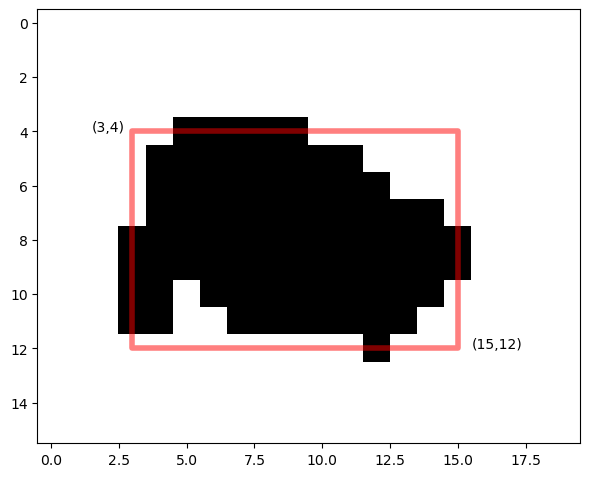

In [37]:
_, (ax1) = plt.subplots(1, 1, figsize=(7, 7), dpi=100)

ax1.imshow(seg_img, cmap='bone_r')

xw = (xmax-xmin)
yw = (ymax-ymin)

c_bbox = [Rectangle(xy=(ymin, xmin),
                    width=yw,
                    height=xw
                    )]
c_bb_patch = PatchCollection(c_bbox,
                             facecolor='none',
                             edgecolor='red',
                             linewidth=4,
                             alpha=0.5)
ax1.add_collection(c_bb_patch);
ax1.text(1.5,4,'({0},{1})'.format(ymin,xmin))
ax1.text(15.5,12,'({0},{1})'.format(ymax,xmax));

# Using regionprops on real images
So how can we begin to apply the tools we have developed?

We take the original car scene from before.

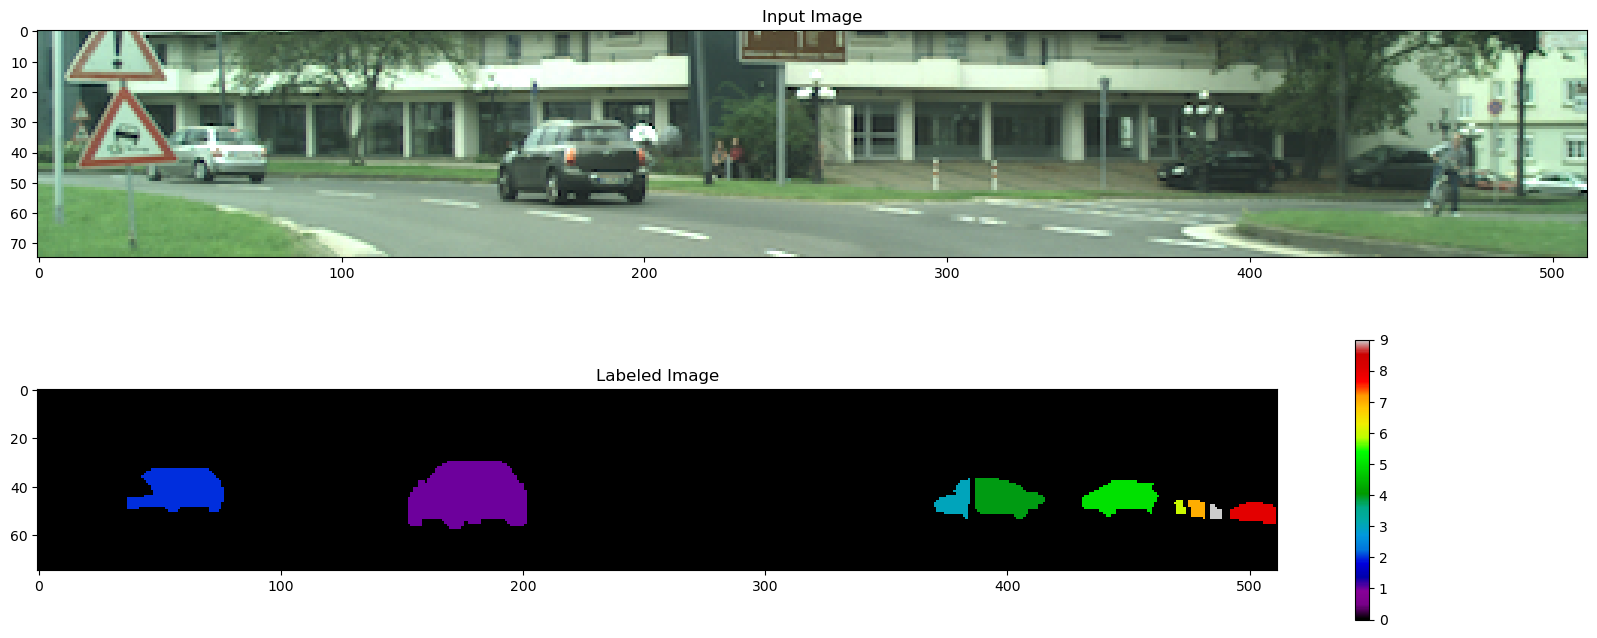

In [38]:
car_img = np.clip(imread('figures/aachen_img.png')
                  [75:150]*2.0, 0, 255).astype(np.uint8)
lab_img = label(imread('figures/aachen_label.png')[::4, ::4] == 26)[75:150]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 8))
ax1.imshow(car_img)
ax1.set_title('Input Image');

plt.colorbar(ax2.imshow(lab_img, cmap='nipy_spectral',interpolation='None'))
ax2.set_title('Labeled Image');

## Shape Analysis
We can perform shape analysis and calculate basic shape parameters for each object

In [39]:
regs = regionprops_table(lab_img,properties=['label','centroid','bbox'])
attr_df=pd.DataFrame.from_dict(regs, orient="index")
attr_df

,0,1,2,3,4,5,6,7,8
label,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.00
centroid-0,43.645280,41.442991,45.871429,44.862573,44.526316,48.636364,49.090909,50.992537,50.92
centroid-1,177.822181,58.760748,378.664286,398.669591,446.913313,471.181818,478.227273,501.820896,485.76
bbox-0,30.000000,33.000000,37.000000,37.000000,38.000000,46.000000,46.000000,47.000000,48.00
bbox-1,153.000000,37.000000,370.000000,387.000000,431.000000,469.000000,475.000000,492.000000,484.00
bbox-2,58.000000,51.000000,54.000000,54.000000,53.000000,52.000000,54.000000,56.000000,54.00
bbox-3,202.000000,77.000000,385.000000,416.000000,463.000000,474.000000,482.000000,511.000000,489.00


### Showing the properties in the image

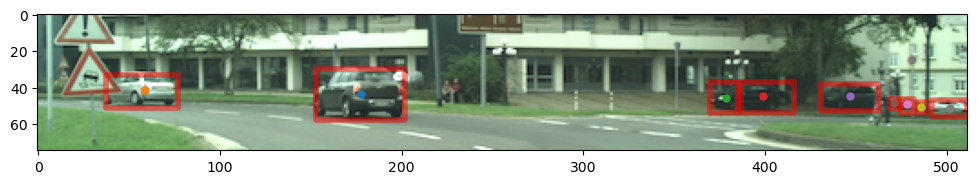

In [40]:
fig, ax1 = plt.subplots(1, 1, figsize=(12, 6), dpi=100)
ax1.imshow(car_img)

bbox_list = []
for idx in range(len(regs['centroid-0'])):
    ax1.plot(regs['centroid-1'][idx], regs['centroid-0'][idx], 'o', markersize=5)
    bbox_list += [Rectangle(xy=(regs['bbox-1'][idx],
                                regs['bbox-0'][idx]),
                                width  =regs['bbox-3'][idx]-regs['bbox-1'][idx],
                                height =regs['bbox-2'][idx]-regs['bbox-0'][idx]
                            )]
c_bb_patch = PatchCollection(bbox_list,
                             facecolor='none',
                             edgecolor='red',
                             linewidth=4,
                             alpha=0.5)
ax1.add_collection(c_bb_patch);

## Statistics
We can then generate a table full of these basic parameters for each object. In this case, we add color as an additional description

In [41]:
def ed_img(in_img):
    # shrink an image to a few pixels
    cur_img = in_img.copy()
    while cur_img.max() > 0:
        last_img = cur_img
        cur_img = erosion(cur_img, disk(1))
    return last_img

## Assign color using a KNN classifier

In [42]:
from matplotlib import colors as mcolors
from sklearn.neighbors import KNeighborsClassifier

# Get color names and RGB values from matplotlib
color_names = list(mcolors.CSS4_COLORS.keys())
color_rgbs = [mcolors.to_rgb(mcolors.CSS4_COLORS[name]) for name in color_names]
color_rgbs = np.array(color_rgbs) * 255  # Convert to 0–255 RGB range

# Fit 1-NN classifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(color_rgbs, color_names)

#
reg_df = pd.DataFrame.from_dict(regs)
reg_df['color'] = reg_df['label'].apply(lambda c_reg: knn.predict(np.mean(car_img[ed_img(lab_img == c_reg)], 0)[:3].reshape((1, -1)))[0])
reg_df

,label,centroid-0,centroid-1,bbox-0,bbox-1,bbox-2,bbox-3,color
0,1,43.645280,177.822181,30,153,58,202,dimgray
1,2,41.442991,58.760748,33,37,51,77,silver
2,3,45.871429,378.664286,37,370,54,385,darkslategray
3,4,44.862573,398.669591,37,387,54,416,darkslategray
4,5,44.526316,446.913313,38,431,53,463,darkslategray
5,6,48.636364,471.181818,46,469,52,474,dimgray
6,7,49.090909,478.227273,46,475,54,482,dimgray
7,8,50.992537,501.820896,47,492,56,511,powderblue
8,9,50.920000,485.760000,48,484,54,489,gray


### Does it make sense?

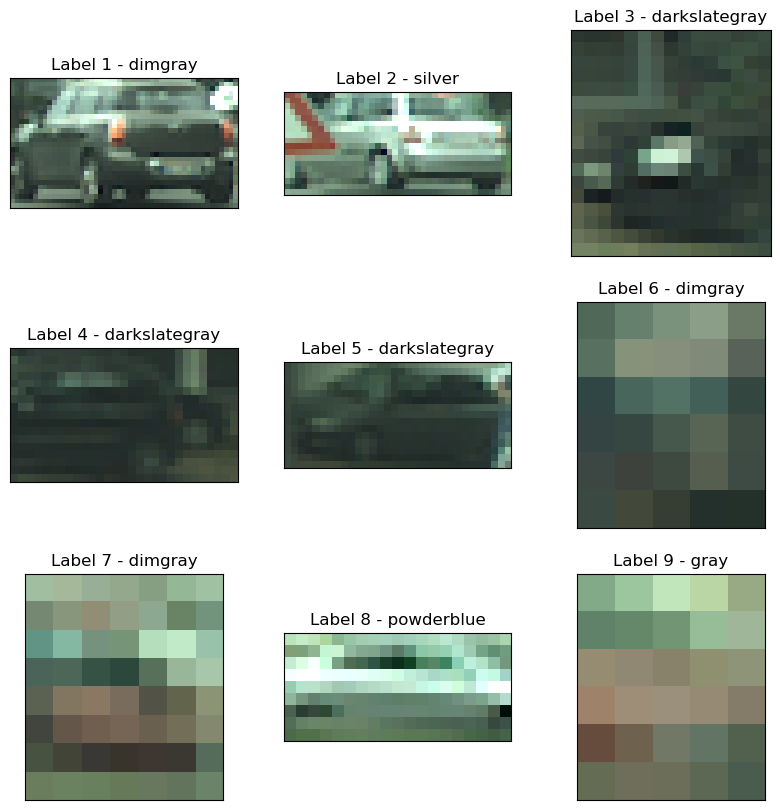

In [43]:
fig, m_axs = plt.subplots(np.floor(len(regs['centroid-0'])/3).astype(int),3, figsize=(10,10))
for idx,c_ax in enumerate(m_axs.ravel()):
    c_ax.imshow(car_img[regs['bbox-0'][idx]:regs['bbox-2'][idx],regs['bbox-1'][idx]:regs['bbox-3'][idx]])
    c_ax.set(xticks=[],yticks=[],title='Label {0} - {1}'.format(regs['label'][idx],reg_df['color'][idx]))


# Object anisotropy

## Anisotropy: What is it?

By definition (New Oxford American): __varying in magnitude according to the direction of measurement.__
<br/><br/><br/><br/>
It allows us to define metrics in respect to one another and thereby characterize shape.
- Is it:
    - tall and skinny, 
    - short and fat, 
    - or perfectly round?

## A very vague definition
It can be mathematically characterized in many different very much unequal ways (in all cases 0 represents a sphere)

$$ A_{iso1} = \frac{\text{Longest Side}}{\text{Shortest Side}} - 1 $$
<br/><br/>
$$ A_{iso2} = \frac{\text{Longest Side}-\text{Shortest Side}}{\text{Longest Side}} $$
<br/><br/>
$$ A_{iso3} = \frac{\text{Longest Side}}{\text{Average Side Length}} - 1 $$
<br/><br/>
$$ A_{iso4} = \frac{\text{Longest Side}-\text{Shortest Side}}{\text{Average Side Length}} $$
<br/><br/>
$$ \cdots \rightarrow \text{ ad nauseum} $$

In [44]:
from collections import defaultdict
from skimage.measure import regionprops
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Let's define some of these metrics

In [45]:
xx, yy = np.meshgrid(np.linspace(-5, 5, 100),
                     np.linspace(-5, 5, 100))


def side_len(c_reg): return sorted(
    [c_reg.bbox[3]-c_reg.bbox[1], c_reg.bbox[2]-c_reg.bbox[0]])


aiso_funcs = [lambda x:  side_len(x)[-1]/side_len(x)[0]-1,
              lambda x: (side_len(x)[-1]-side_len(x)[0])/side_len(x)[-1],
              lambda x:  side_len(x)[-1]/np.mean(side_len(x))-1,
              lambda x: (side_len(x)[-1]-side_len(x)[0])/np.mean(side_len(x))]


def ell_func(a, b): return np.sqrt(np.square(xx/a)+np.square(yy/b)) <= 1

### How does the anisotropy metrics respond?

In this demonstration, we look into how the four different anisotropy metrics respond to different radius ratios of an ellipse. The ellipse is nicely aligned with the x- and y- axes, therefore we can use the bounding box to identify the side lengths as diameters in the two directions. These side lengths will be used to compute the aniotropy with our four metrics.

Much of the code below is for the animated display.

In [46]:
ab_list = [(2, 2), (2, 3), (2, 4), (2, 5), (1.5, 5),
           (1, 5), (0.5, 5), (0.1, 5),  (0.05, 5)]
func_pts = defaultdict(list)

fig, m_axs = plt.subplots(2, 3, figsize=(9, 6), dpi=100)

def update_frame(i):
    plt.cla()
    a, b     = ab_list[i]
    c_img    = ell_func(a, b)
    reg_info = regionprops(c_img.astype(int))[0]
    m_axs[0, 0].imshow(c_img, cmap='gist_earth')
    m_axs[0, 0].set_title('Shape #{}'.format(i+1))
    m_axs2=[m_axs[0,1],m_axs[0,2],m_axs[1,1],m_axs[1,2]]
    
    for j, (c_func, c_ax) in enumerate(zip(aiso_funcs, m_axs2), 1):
        func_pts[j] += [c_func(reg_info)]
        c_ax.plot(func_pts[j], 'r-')
        c_ax.set_title('Anisotropy #{}'.format(j))
        c_ax.set_ylim(-.1, 3)
    m_axs[1,0].axis('off')


# write animation frames
anim_code = FuncAnimation(fig,
                          update_frame,
                          frames=len(ab_list)-1,
                          interval=500,
                          repeat_delay=2000).to_html5_video()
plt.close('all')
HTML(anim_code)

# Statistical tools

## Useful Statistical Tools

While many of the topics covered in 

- Linear Algebra 
- and Statistics courses 

might not seem very applicable to real problems at first glance.

at least a few of them come in handy for dealing distributions of pixels 

_(they will only be briefly covered, for more detailed review look at some of the suggested material)_

## Principal Component Analysis - PCA
- Similar to K-Means insofar as we start with a series of points in a vector space and want to condense the information. 

With PCA
- doesn't search for distinct groups, 
- we find a linear combination of components which best explain the variance in the system.

To read
[Principal component analysis: a review and recent developments](https://doi.org/10.1098/rsta.2015.0202)

## PCA definition

1. Compute the covariance or correlation matrix from a set of images
$$C = cov(X_1, \ldots X_N)$$
2. Make an Eigen value or Singular Value Decomposition
$$C=Q\Lambda{}Q^{-1}$$
3. Use 
    - singular values, $\Lambda$, to measure the importance of each eigen value 
    - eigen vectors, $Q$, to transform the data

PCA explains structure by:

- Rotating to directions that show the most variation. $Q$ is a rotation matrix.
- Revealing latent patterns, redundancy, and clusters. Great $\lambda$ represent data.
- Reducing noise by discarding low-variance directions. Low $\lambda$ low data content.
- Providing a new coordinate system aligned with your data’s geometry

## PCA on spectroscopy
As an example we will use a very simple (simulated) example from spectroscopy:

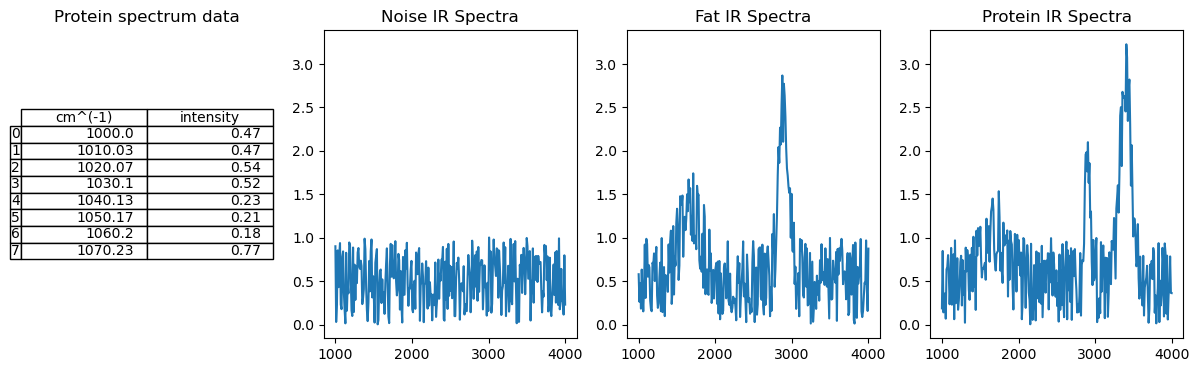

In [47]:
cm_dm = np.linspace(1000, 4000, 300)

# helper functions to build our test data
def peak(cent, wid, h): return h/(wid*np.sqrt(2*np.pi)) * \
    np.exp(-np.square((cm_dm-cent)/wid))

def peaks(plist): return np.sum(np.stack(
    [peak(cent, wid, h) for cent, wid, h in plist], 0), 0)+np.random.uniform(0, 1, size=cm_dm.shape)

# Define material spectra
fat_curve     = [(2900, 100, 500), (1680, 200, 400)]
protein_curve = [(2900, 50, 200), (3400, 100, 600), (1680, 200, 300)]
noise_curve   = [(3000, 50, 1)]

# Plotting
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[2].plot(cm_dm, peaks(fat_curve));     ax[2].set_title('Fat IR Spectra')
ax[3].plot(cm_dm, peaks(protein_curve)); ax[3].set_title('Protein IR Spectra')
ax[1].plot(cm_dm, peaks(noise_curve));   ax[1].set_title('Noise IR Spectra')
ax[1].set_ylim(ax[3].get_ylim())
ax[2].set_ylim(ax[3].get_ylim())
data=pd.DataFrame({'cm^(-1)': cm_dm, 'intensity': peaks(protein_curve)}).head(8)
pd.plotting.table(data=data.round(decimals=2), ax=ax[0], loc='center'); ax[0].axis('off'); ax[0].set_title('Protein spectrum data');

## Test Dataset of a number of curves
We want to sort cells or samples into groups of being 
- more fat like 
- or more protein like. 

We generate 20 noisy spectra for each type

### How can we analyze this data without specifically looking for peaks or building models?

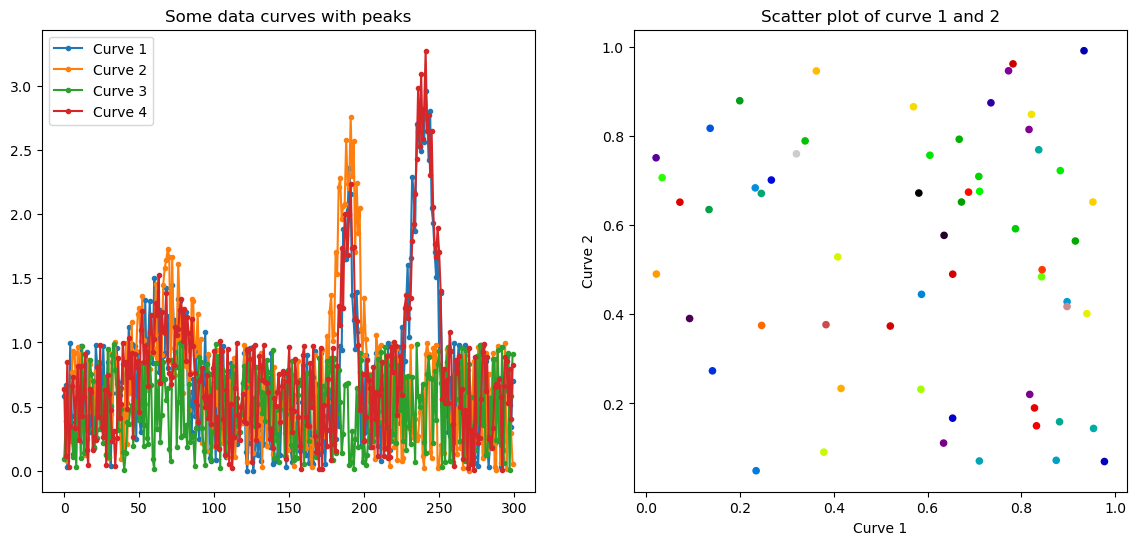

In [48]:
test_data = np.stack([peaks(c_curve) for _ in range(20)
                      for c_curve in [protein_curve, fat_curve, noise_curve]], 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(test_data[:4].T, '.-')
ax1.legend(['Curve 1', 'Curve 2', 'Curve 3', 'Curve 4'])
ax1.set_title('Some data curves with peaks')
ax2.scatter(test_data[:, 0], test_data[:,1], c=range(test_data.shape[0]),
            s=20, cmap='nipy_spectral')
ax2.set_title('Scatter plot of curve 1 and 2'); ax2.set_xlabel('Curve 1'); ax2.set_ylabel('Curve 2'); 

We see some peaks, but it is hard to tell one type from the other.

### Fit the data with PCA

We expect high correlation within three groups among the 60 spectra. Let's make a PCA analysis with some more components to see the effect of the noise in the data. We select five components for our PCA. PCA is a very common way for preanalysis and data reduction that there is already a function in SciKit Learn.

In [49]:
from sklearn.decomposition import PCA
pca_tool = PCA(5)
pca_tool.fit(test_data)

PCA(n_components=5)

### How important is each component?

Let's first look at the eigenvalues of the PCA. Here, we can already tell that most of the signal energy resides in the first two components, i.e. there is great redundancy in the data. This is expected given the nature of the data with two spectra containing relevant protein information while the last only contains noise.

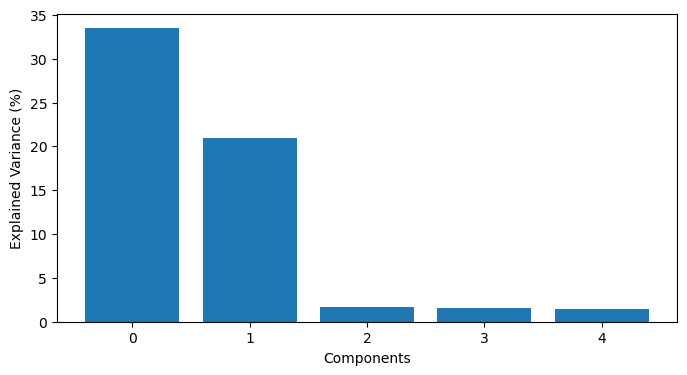

In [50]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 4), dpi=100)
ax1.bar(x=range(pca_tool.explained_variance_ratio_.shape[0]),
        height=100*pca_tool.explained_variance_ratio_)
ax1.set_xlabel('Components')
ax1.set_ylabel('Explained Variance (%)');

### Plot principal components

The next step is to look at the eigen vectors of the PCA which tells how to transform the signals to obtain the greatest separation between the classes. 

The eigen vectors of the first three eigen values confirm that the first two components provide relevant information about the peaks while the third essentially only show noise.

In [51]:
score_matrix = pca_tool.transform(test_data)

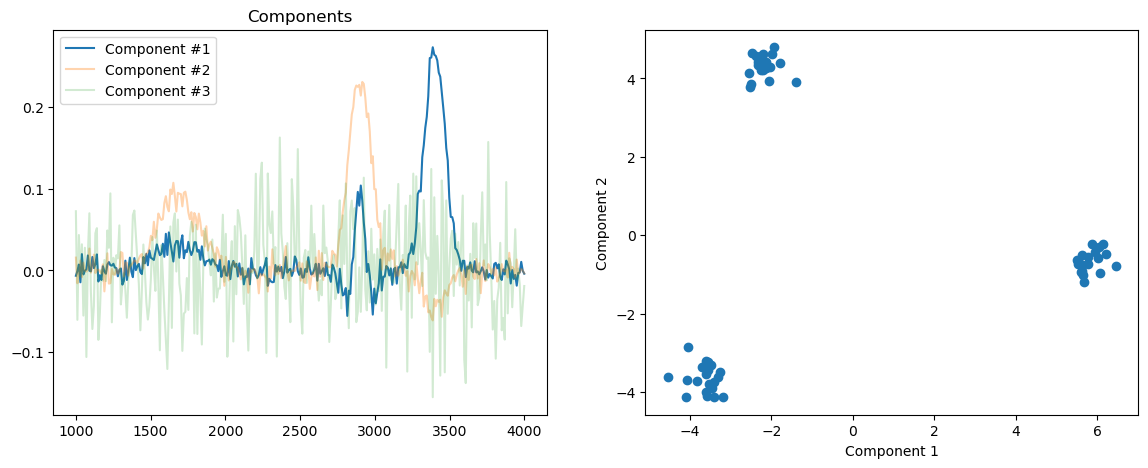

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5),dpi=100)
ax1.plot(cm_dm, pca_tool.components_[0, :], label='Component #1')
ax1.plot(cm_dm, pca_tool.components_[
         1, :], label='Component #2', alpha=pca_tool.explained_variance_ratio_[0])
ax1.plot(cm_dm, pca_tool.components_[
         2, :], label='Component #3', alpha=pca_tool.explained_variance_ratio_[1])
ax1.legend(), ax1.set_title('Components')
ax2.scatter(score_matrix[:, 0],
            score_matrix[:, 1])
ax2.set_xlabel('Component 1')
ax2.set_ylabel('Component 2');

Now, using components 1 and 2 to transform the specta we get a nice separation between the signals when we look at the scatter plot. This can now be used to classify the signals into their expected three categories using for example k-means clustering.

### PCA - Common Pitfalls

|Mistake | Why it's a problem |
|:--|:--|
|Not standardizing the data | PCA is sensitive to scale, always normalize first! |
|Over-interpreting low-variance PCs|They may contain noise |
|Misreading sign of loadings | Sign is arbitrary; focus on relative magnitude |


# PCA in materials science

Explore crystal textures in metals.

## Bragg edge imaging - the imaging technique
- Wavelength resolved neutron imaging provides spectral images
- Crystaline properties can be explored in the spectra
- Bragg edges appear when the Bragg criterion is fulfilled
$$2d\sin{\theta}=n\lambda{}$$

![](figures/Braggs_Law.png)

Neutrons in the thermal and cold spectrum have wavelengths in the same scale as the lattice distances in many metals. Neutrons can be used to probe the crystal structure using diffraction thanks to this relation. 

The diffraction can cause constructive and destructive interference depending on the match between wavelength, observation angle and lattice distances. The imaging method probes the sample in transmission at different wavelengths and each material will show a characteristic spectral transmission pattern per pixel.

## Bragg edge imaging example
|Samples| Spectrum| Wavelength scan|
|:---:|:---:|:---:|
|![](figures/icon-spectrum.png)|![](figures/energysamples.png)|![](figures/energy_scan.png)|

Images courtesy of S. Peetermans

The iron power spectrum is shown together with the neutron source spectrum. The sharp edges in the spectrum are caused at the wavelengths where the Bragg condition is fulfilled.
A collection of different materials was tested in this example. The Fe pieces are of particular interest as one sample is poly crystaline while the other is a single crystal.


## Bragg edge imaging and PCA 

### The data

The images in this example come from a neutron wavelength scan of six steel samples produced by additive manufacturing (3D printed). The spectra are supposed to show how the crystal structure change depending on printing method and further treatment.

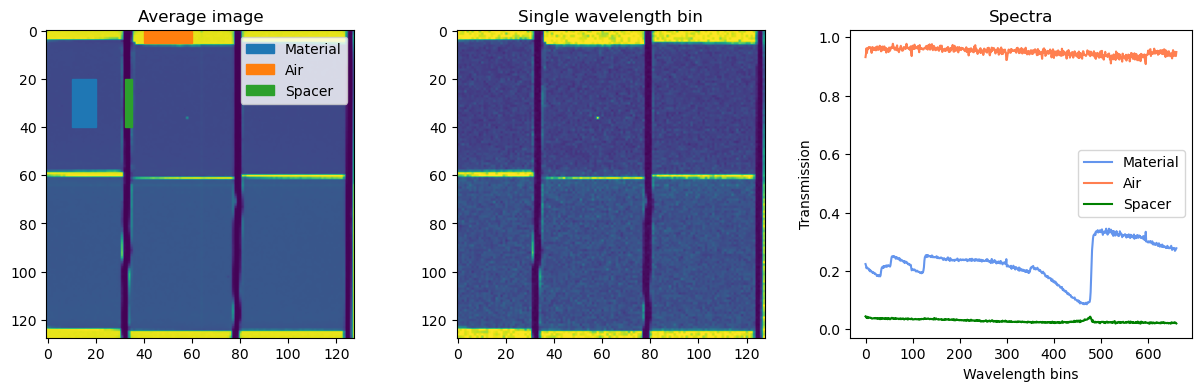

In [53]:
data=np.load('data/tofdata.npy')
fig,ax=plt.subplots(1,3,figsize=(15,4),dpi=100)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

ax[0].imshow(data.mean(axis=2), cmap='viridis'), ax[0].set_title('Average image');
ax[0].add_patch(Rectangle(xy=(10, 20), width =10, height = 20, facecolor=colors[0], edgecolor=colors[0], label = "Material"))
ax[0].add_patch(Rectangle(xy=(40, 0),  width =20, height = 5,  facecolor=colors[1], edgecolor=colors[1], label="Air"))
ax[0].add_patch(Rectangle(xy=(32, 20), width =3,  height = 20, facecolor=colors[2], edgecolor=colors[2],label="Spacer"))
ax[0].legend()

ax[1].imshow(data[:,:,100], cmap='viridis'), ax[1].set_title('Single wavelength bin');
ax[2].plot(data[20:40,10:20].mean(axis=0).mean(axis=0), color='Cornflowerblue', label = 'Material');
ax[2].plot(data[0:5,40:60].mean(axis=0).mean(axis=0),   color='coral',          label = 'Air');
ax[2].plot(data[20:40,32:35].mean(axis=0).mean(axis=0), color='green',          label = 'Spacer');
ax[2].set_title('Spectra'); ax[2].set_xlabel('Wavelength bins'); ax[2].set_ylabel('Transmission'); ax[2].legend();

You can see in the plots that there is only diffraction response in the steel area. The other two areas are not affected by the change in wavelength only by the attenuation coefficient.

### Prepare the data for analysis

1. Rearrange the images into 1D arrays $M\times{}N\times{}T\rightarrow{}M\cdot{}N\times{}T$

The first preparation step is to reshape the images from 2D to 1D and thus giving a 1D array per spectral bin. This is needed to be able to compute the covariance matrix.

In [54]:
fdata=data.reshape(data.shape[0]*data.shape[1],data.shape[2])

2. Compute mean and standard deviation

In [55]:
m  = np.reshape(fdata.mean(axis=0),(1,fdata.shape[1]))
mm = np.ones((fdata.shape[0],1))*m
s  = np.reshape(fdata.std(axis=0),(1,fdata.shape[1]))
ss = np.ones((fdata.shape[0],1))*m

3. Normalize data

In [56]:
mfdata=(fdata-mm)/ss

### Run the PCA

1. Initialize PCA with 5 components

In [57]:
pca_tool = PCA(5)

2. Fit data with PCA

In [58]:
pca_tool.fit(mfdata)

PCA(n_components=5)

### Inspect the PCA fit

In [59]:
score_matrix = pca_tool.transform(mfdata)

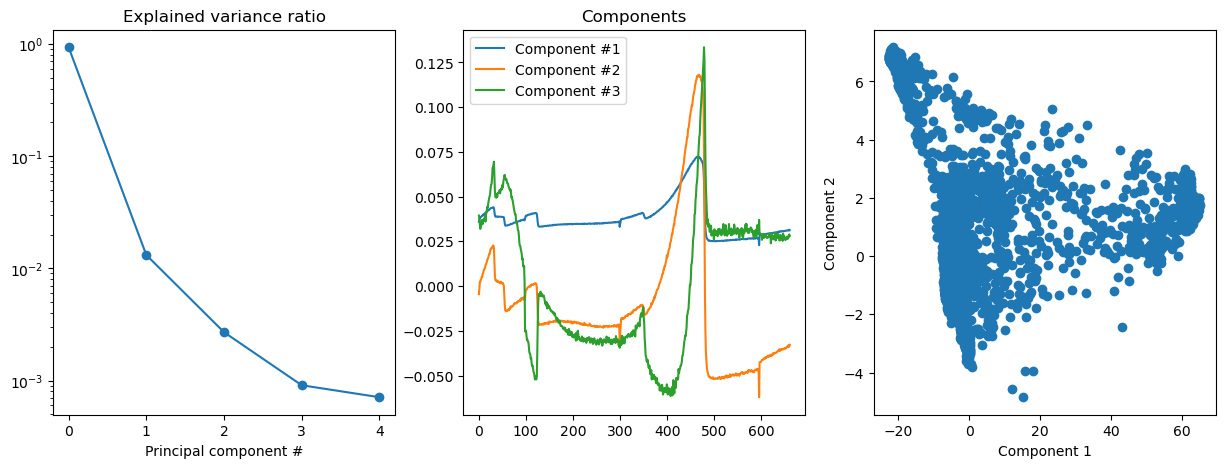

In [60]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5),dpi=100)
ax[0].semilogy(pca_tool.explained_variance_ratio_,'o-'); 
ax[0].set_title('Explained variance ratio'); ax[0].set_xlabel('Principal component #')
ax[1].plot(pca_tool.components_[0, :], label='Component #1')
ax[1].plot(pca_tool.components_[1, :], label='Component #2')
ax[1].plot(pca_tool.components_[2, :], label='Component #3')
ax[1].legend(); ax[1].set_title('Components')
ax[2].scatter(score_matrix[:, 0], score_matrix[:, 1]); ax[2].set_xlabel('Component 1'); ax[2].set_ylabel('Component 2');

### Improve the scatter plot

The scatter plot of the data is very dense and it is not easy to spot the peaks of the clusters. This can be addressed by changing the opacity of the plotted dots. Below you see an example where the opacity value $\alpha$ was set to 5%. The clusters now appear much clearer than before.

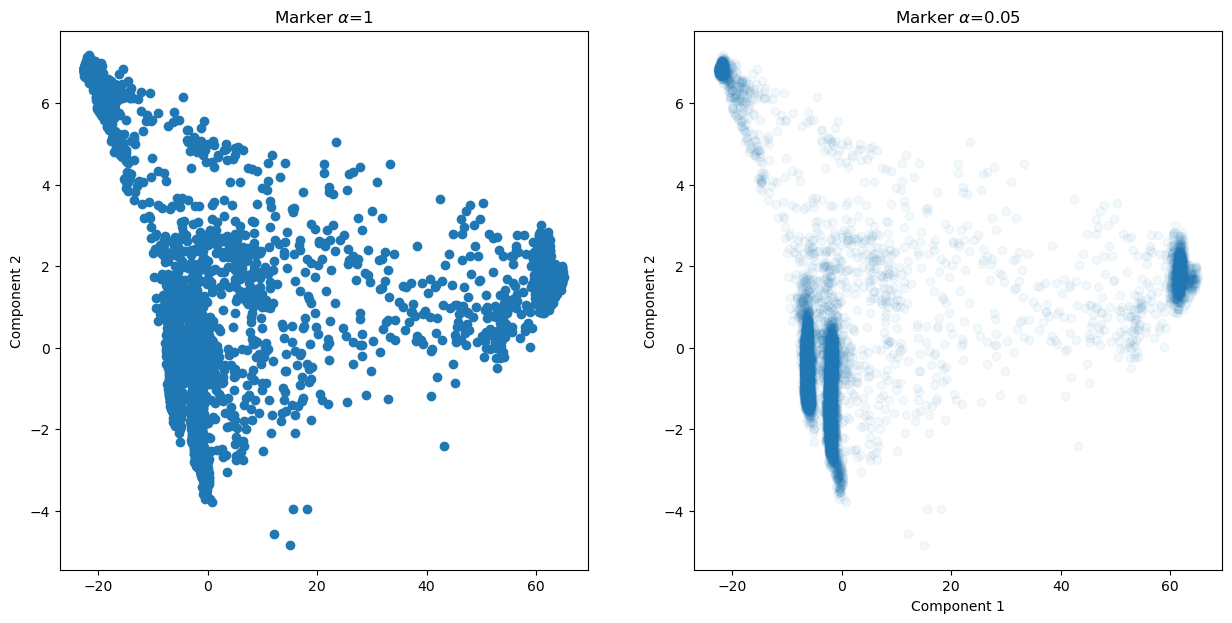

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].scatter(score_matrix[:, 0], score_matrix[:, 1]); 
ax[1].set_xlabel('Component 1'); ax[0].set_ylabel('Component 2');
ax[0].set_title(r'Marker $\alpha$=1');

ax[1].scatter(score_matrix[:, 0], score_matrix[:, 1], alpha=0.05); 
ax[1].set_xlabel('Component 1'); ax[1].set_ylabel('Component 2');
ax[1].set_title(r'Marker $\alpha$=0.05');

### Visualize the PCAs with color coding
Inspired by [PCA in materials science](https://doi.org/10.1088/2399-6528/ab5575)

In [ ]:
# Reshape the first three principal components
cdata = score_matrix[:,:3].reshape([data.shape[0],data.shape[1],3])

# Normalize the chanels
for i in range(3) :
    cdata[:,:,i]=(cdata[:,:,i]-cdata[:,:,i].min())/(cdata[:,:,i].max()-cdata[:,:,i].min())
    

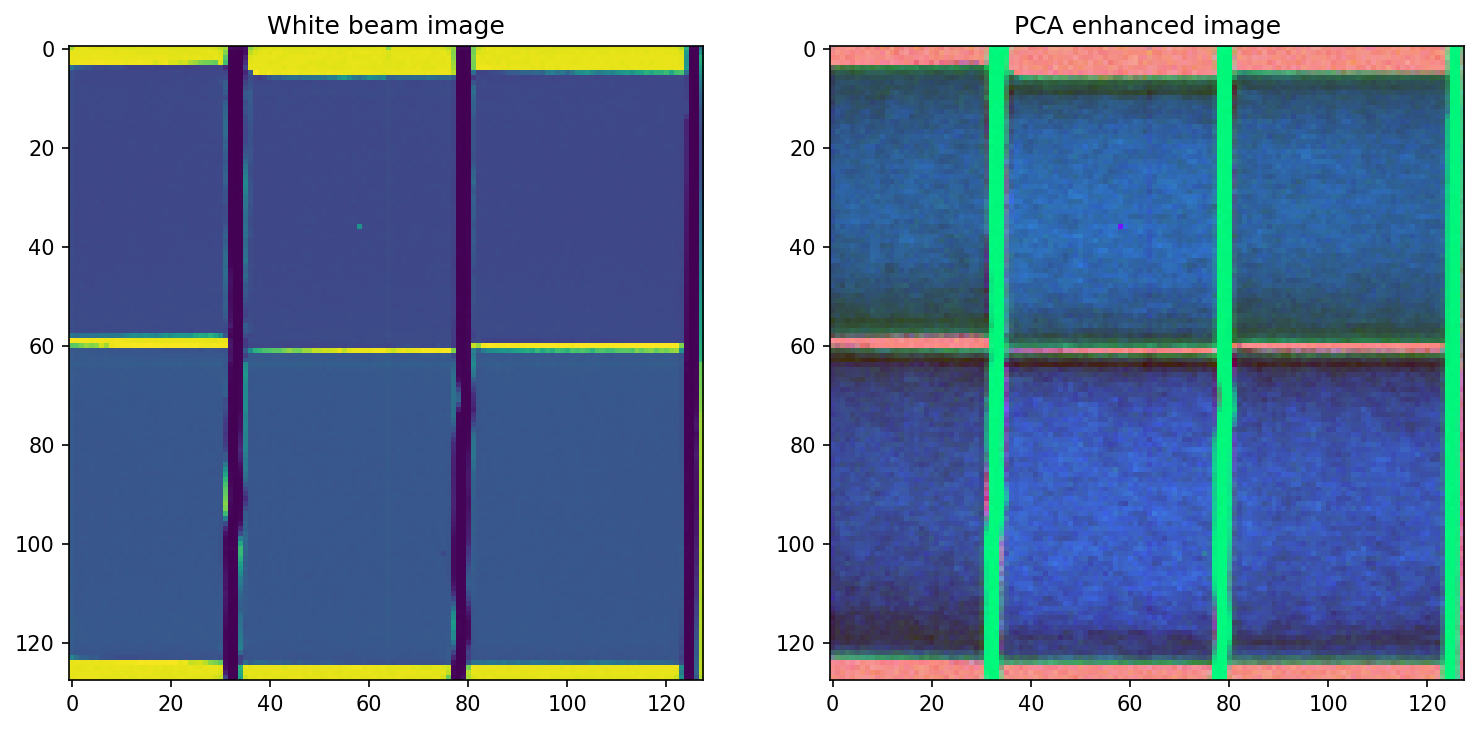

In [62]:
fig, ax = plt.subplots(1,2,figsize=(12,6), dpi=150)
ax[0].imshow(data.mean(axis=2)); ax[0].set_title('White beam image')
ax[1].imshow(cdata); ax[1].set_title('PCA enhanced image');

The PCA enhanced image does not represent a physical reality, but it can be used as a qualitative tool to guide the material analysis.

### PCA and segmentation

The next step is to use the enhanced image for segmentation:

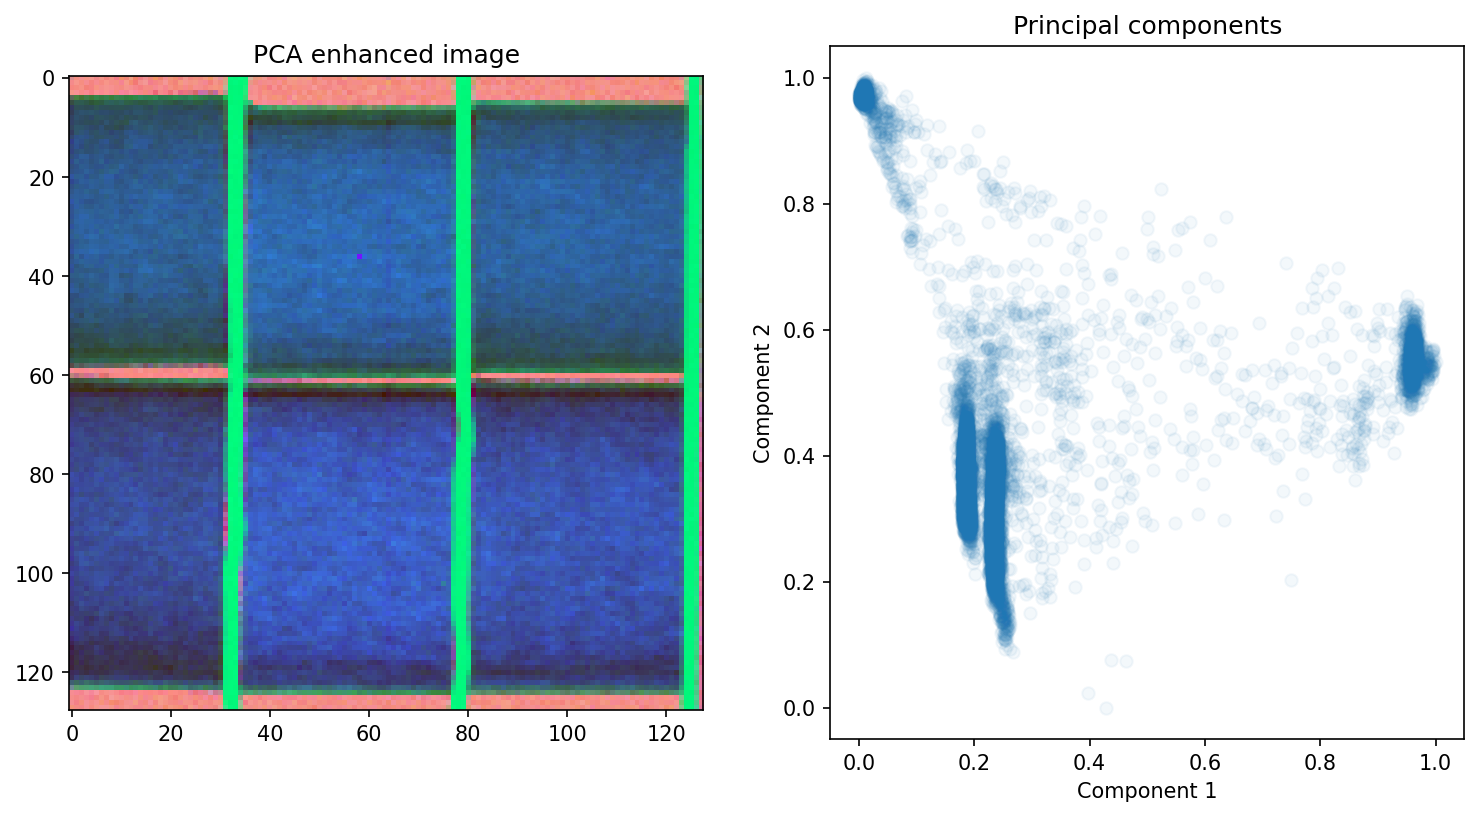

In [63]:
fig, ax = plt.subplots(1,2,figsize=(12,6), dpi=150)
ax[0].imshow(cdata); ax[0].set_title('PCA enhanced image');
ax[1].scatter(score_matrix[:, 0], score_matrix[:, 1], alpha=0.05); ax[1].set_xlabel('Component 1'); ax[1].set_ylabel('Component 2');
ax[1].set_title(r'Principal components');

A project task...
1. Combine clustering and PCA to identify regions in the samples

## SciKit-learn [Face Analyis](http://scikit-learn.org/stable/auto_examples/decomposition/plot_faces_decomposition.html)

This is another example of using PCA in image analysis. It is not covered during the lecture and provided fo the interested reader. 
Here we show a more imaging related example from the scikit-learn documentation where we do basic face analysis with scikit-learn.


In [64]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn import decomposition
# Load faces data
try:
    dataset = fetch_olivetti_faces(
        shuffle=True, random_state=2018, data_home='.')
    faces = dataset.data
except Exception as e:
    print('Face data not available', e)
    faces = np.random.uniform(0, 1, (400, 4096))

n_samples, n_features = faces.shape
n_row, n_col = 2, 3
n_components = n_row * n_col
image_shape = (64, 64)

# global centering
faces_centered = faces - faces.mean(axis=0)

# local centering
faces_centered -= faces_centered.mean(axis=1).reshape(n_samples, -1)

print("Dataset consists of %d faces" % n_samples)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to .
Dataset consists of 400 faces


Extracting the top 6 Eigenfaces - PCA using randomized SVD...


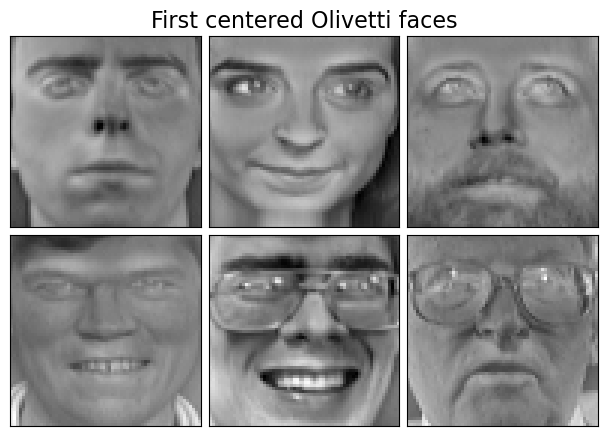

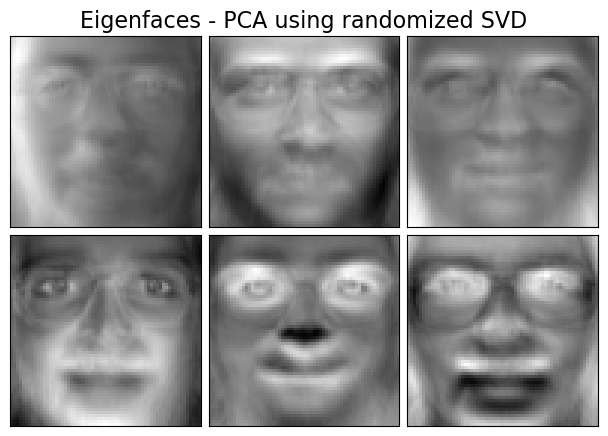

In [65]:
def plot_gallery(title, images, n_col=n_col, n_row=n_row):
    plt.figure(figsize=(2. * n_col, 2.26 * n_row))
    plt.suptitle(title, size=16)
    for i, comp in enumerate(images):
        plt.subplot(n_row, n_col, i + 1)
        vmax = max(comp.max(), -comp.min())
        plt.imshow(comp.reshape(image_shape), cmap=plt.cm.gray,
                   interpolation='nearest',
                   vmin=-vmax, vmax=vmax)
        plt.xticks(())
        plt.yticks(())
    plt.subplots_adjust(0.01, 0.05, 0.99, 0.93, 0.04, 0.)


# #############################################################################
# List of the different estimators, whether to center and transpose the
# problem, and whether the transformer uses the clustering API.
estimators = [
    ('Eigenfaces - PCA using randomized SVD',
     decomposition.PCA(n_components=n_components, svd_solver='randomized',
                       whiten=True),
     True)]
# #############################################################################
# Plot a sample of the input data

plot_gallery("First centered Olivetti faces", faces_centered[:n_components])

# #############################################################################
# Do the estimation and plot it

for name, estimator, center in estimators:
    print("Extracting the top %d %s..." % (n_components, name))
    data = faces
    if center:
        data = faces_centered
    estimator.fit(data)

    if hasattr(estimator, 'cluster_centers_'):
        components_ = estimator.cluster_centers_
    else:
        components_ = estimator.components_
    plot_gallery(name,
                 components_[:n_components])

plt.show()

# Applied PCA: Shape Tensor

## How do these statistical analyses help us?
Going back to a single cell, we have the a distribution of $x$ and $y$ values.
- are not however completely independent
- greatest variance does not normally lie in either x nor y alone. 

A principal component analysis of the voxel positions, will calculate two new principal components (the components themselves are the relationships between the input variables and the scores are the final values.)
- An optimal rotation of the coordinate system

We start off by calculating the covariance matrix from the list of $x$, $y$, and $z$ points that make up our object of interest.

$$ COV(I_{id}) = \frac{1}{N} \sum_{\forall\vec{v}\in I_{id}} \begin{bmatrix}
\vec{v}_x\vec{v}_x & \vec{v}_x\vec{v}_y & \vec{v}_x\vec{v}_z\\
\vec{v}_y\vec{v}_x & \vec{v}_y\vec{v}_y & \vec{v}_y\vec{v}_z\\
\vec{v}_z\vec{v}_x & \vec{v}_z\vec{v}_y & \vec{v}_z\vec{v}_z
\end{bmatrix} $$

We then take the eigentransform of this array to obtain the eigenvectors (principal components, $\vec{\Lambda}_{1\cdots 3}$) and eigenvalues (scores, $\lambda_{1\cdots 3}$)

$$ COV(I_{id}) \longrightarrow \underbrace{\begin{bmatrix}
\vec{\Lambda}_{1x} & \vec{\Lambda}_{1y} & \vec{\Lambda}_{1z} \\
\vec{\Lambda}_{2x} & \vec{\Lambda}_{2y} & \vec{\Lambda}_{2z} \\
\vec{\Lambda}_{3x} & \vec{\Lambda}_{3y} & \vec{\Lambda}_{3z} 
\end{bmatrix}}_{\textrm{Eigenvectors}} * \underbrace{\begin{bmatrix} 
\lambda_1 & 0 & 0 \\ 
0 & \lambda_2 & 0 \\
0 & 0 & \lambda_3
\end{bmatrix}}_{\textrm{Eigenvalues}} * \underbrace{\begin{bmatrix}
\vec{\Lambda}_{1x} & \vec{\Lambda}_{1y} & \vec{\Lambda}_{1z} \\
\vec{\Lambda}_{2x} & \vec{\Lambda}_{2y} & \vec{\Lambda}_{2z} \\
\vec{\Lambda}_{3x} & \vec{\Lambda}_{3y} & \vec{\Lambda}_{3z} 
\end{bmatrix}^{T}}_{\textrm{Eigenvectors}} $$
The principal components tell us about the orientation of the object and the scores tell us about the corresponding magnitude (or length) in that direction.

## Testing orientation analysis

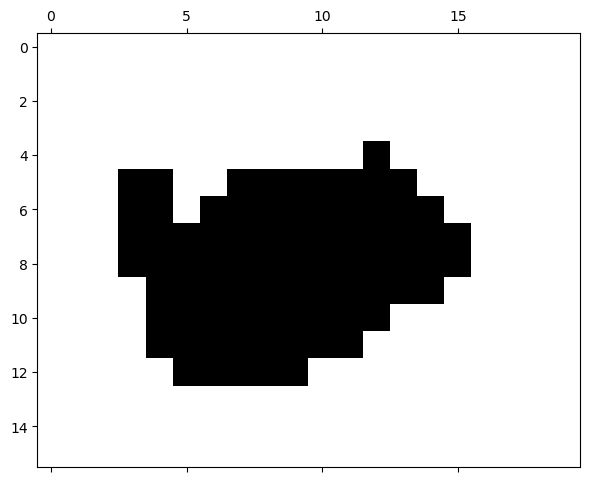

In [66]:
seg_img = imread('figures/aachen_label.png') == 26
seg_img = seg_img[::4, ::4]
seg_img = seg_img[130:110:-2, 378:420:3] > 0
seg_img = np.pad(seg_img, 3, mode='constant')
seg_img[0, 0] = 0
_, (ax1) = plt.subplots(1, 1, figsize=(7, 7), dpi=100)
ax1.matshow(seg_img, cmap='bone_r');

### Eigenvectors of the positions

In [73]:
x_coord, y_coord = np.where(seg_img > 0) # Get object coordinates
xy_pts = np.stack([x_coord, y_coord], 1) # Build a N x 2 matrix

shape_pca = PCA()
shape_pca.fit(xy_pts)

PCA()

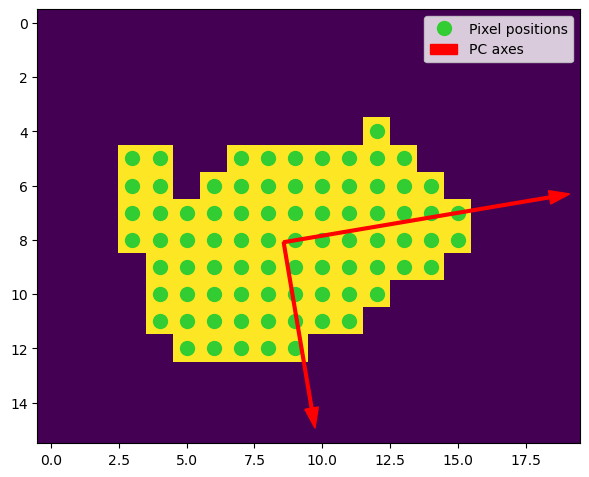

In [74]:
_, (ax1) = plt.subplots(1, 1,
                        figsize=(7, 7),
                        dpi=100)

ax1.imshow(seg_img>0)
ax1.plot(xy_pts[:, 1], xy_pts[:, 0], 'o', color='limegreen', markersize=10,label='Pixel positions',zorder=1);

# draw the eigen vectors 
mean = shape_pca.mean_

for idx,(length, vector) in enumerate(zip(shape_pca.explained_variance_, shape_pca.components_)):
    arrow = vector * np.sqrt(length) * 3  # scale for visibility
    arr=plt.arrow(mean[1], mean[0], arrow[1], arrow[0],
              color='red', width=0.1, head_width=0.5,zorder=2)
    
arr.set_label('PC axes')
    
plt.legend();

### Rotate object using eigenvectors

In [75]:
from sklearn.decomposition import PCA
x_coord, y_coord = np.where(seg_img > 0)      # Get object coordinates
xy_pts      = np.stack([x_coord, y_coord], 1) # Build a N x 2 matrix
shape_pca   = PCA()
shape_pca.fit(xy_pts)
pca_xy_vals = shape_pca.transform(xy_pts)

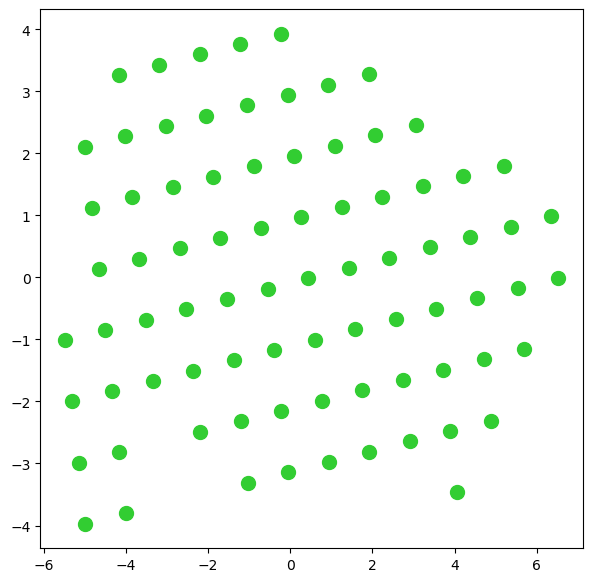

In [76]:
_, (ax1) = plt.subplots(1, 1,
                        figsize=(7, 7),
                        dpi=100)
ax1.plot(pca_xy_vals[:, 0], pca_xy_vals[:, 1], 'o', color='limegreen', markersize=10);

## Principal Component Analysis: Take home message

- We calculate the statistical distribution individually for $x$, $y$, and $z$ and the 'correlations' between them.
- From these values we can estimate the orientation in the direction of largest variance
- We can also estimate magnitude
- These functions are implemented as ```princomp``` or ```pca``` in various languages and scale well to very large datasets.

## Principal Component Analysis: Elliptical Model


While the eigenvalues and eigenvectors are in their own right useful
- Not obvious how to visually represent these tensor objects
- Ellipsoidal (Ellipse in 2D) representation alleviates this issue

### Ellipsoidal Representation
1. Center of Volume is calculated normally
1. Eigenvectors represent the unit vectors for the semiaxes of the ellipsoid
1. $\sqrt{\text{Eigenvalues}}$ is proportional to the length of the semiaxis ($\mathcal{l}=\sqrt{5\lambda_i}$), derivation similar to moment of inertia tensor for ellipsoids.

# What's next?


Bounding box and ellipse-based models are useful for many objects like cells and grains, they do a very poor job with other samples.


## Why
We assume
- an entity consists of connected pixels (wrong)
- the objects are well modeled by an ellipse (also wrong)

## What to do?

- Is it 3 connected objects which should all be analzed seperately?
- If we could __divide it__, we could then analyze each part as an ellipse
- Is it one network of objects and we want to know about the constrictions?
- Is it a cell or organelle with docking sites for cell?
- Neither extents nor anisotropy are very meaningful, we need a __more specific metric__ which can characterize

# Summary

## Component labeling
- What is it
- What is the impact of difference neighborhoods

## Object description
- Center of objects
- Bounding boxes - extents

## Principal component analysis
- Definition
- PCA in spectroscopy
- PCA to analyze shapes